## Import

In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

In [2]:
from ML.utils.utils import *
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator
from physics.Iso_data_handler import Iso_data_handler
from physics.Data_visualiser import Data_visualiser

In [3]:
pre_path = "../../../../../../../"
physical_model = "MIST"
path_to_data = pre_path + "data/MIST_v1.2_vvcrit0.0_basic_isos/"
path_to_results = pre_path + "results/model_A_partial/default_models/"
path_to_predictions = pre_path + "predictions/model_A_partial/default_models/"
tag = "Base"
output_parameters = ['mass', 'radius']
categories_name = ["phase"]

## Data preparation

This notebook contains the results of the model which are trained using all the data from MIST and filtered on the phases

Reading MIST dataframe from csv file...


,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.0,3.486221,3.131342,-1.0,-0.25,0.100000,0.153402
1,5.0,3.487362,3.126808,-1.0,-0.25,0.102645,0.160326
2,5.0,3.489243,3.119367,-1.0,-0.25,0.107039,0.171785
3,5.0,3.491102,3.112165,-1.0,-0.25,0.111419,0.183099
4,5.0,3.492937,3.105143,-1.0,-0.25,0.115789,0.194305
...,...,...,...,...,...,...,...
1467117,10.3,4.402490,7.777159,6.0,0.50,0.532726,-1.806255
1467118,10.3,4.387132,7.783242,6.0,0.50,0.532730,-1.809295
1467119,10.3,4.371789,7.789130,6.0,0.50,0.532735,-1.812237
1467120,10.3,4.356480,7.794844,6.0,0.50,0.532741,-1.815091


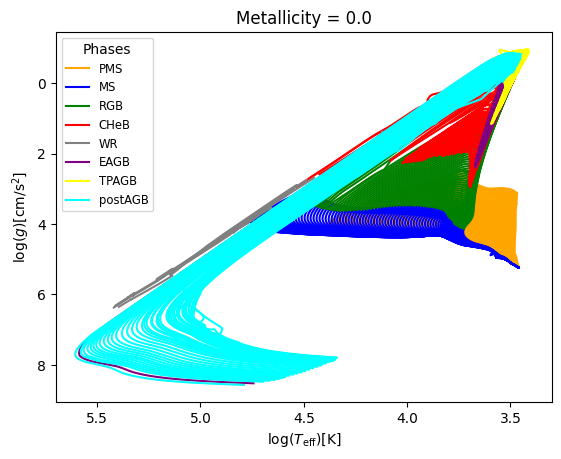

In [4]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'phase', 'metallicity', 'star_mass', 'log_R'], 
                              physical_model, reclassify=True)

iso_df = iso_handler.get_isochrone_dataframe()
display(iso_df)
data_visualiser = Data_visualiser(iso_df, physical_model)
data_visualiser.plot_Kiel([], [0.0])

,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.0,4.494412,4.346972,0.0,-0.25,13.584360,0.610679
1,5.0,4.497517,4.345776,0.0,-0.25,13.765512,0.614753
2,5.0,4.500556,4.344580,0.0,-0.25,13.942887,0.618755
3,5.0,4.504040,4.343050,0.0,-0.25,14.591712,0.624670
4,5.0,4.507576,4.341483,0.0,-0.25,15.426062,0.631187
...,...,...,...,...,...,...,...
633331,10.3,3.602322,1.827453,3.0,0.50,0.866616,1.274247
633332,10.3,3.600999,1.809405,3.0,0.50,0.866614,1.283270
633333,10.3,3.599710,1.791489,3.0,0.50,0.866612,1.292228
633334,10.3,3.598418,1.773621,3.0,0.50,0.866610,1.301161


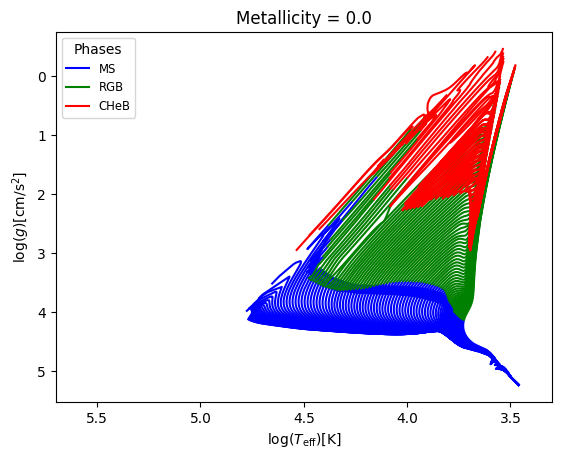

In [5]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'phase':[0, 2, 3]})
display(phase_filtered_iso_df)
data_visualiser_phase_filtered = Data_visualiser(phase_filtered_iso_df, physical_model)
data_visualiser_phase_filtered.plot_Kiel([], [0.0])

In [6]:
print_all_uniques(phase_filtered_iso_df)

log10_isochrone_age_yr  : Range : 5.0 - 10.3, Mean : 8.1222, Median : 8.15

log_Teff  : Range : 3.34 - 5.3788, Mean : 4.0309, Median : 3.9786

log_g  : Range : -1.08 - 7.9405, Mean : 3.515, Median : 3.8557

Values in phase column : 0.0, 2.0, 3.0 

Values in metallicity column : -0.25, -0.5, -0.75, -1.0, -1.25, -1.5, -1.75, -2.0, -2.5, -3.0, -3.5, -4.0, 0.0, 0.25, 0.5 

star_mass  : Range : 0.1 - 298.5448, Mean : 11.3677, Median : 2.8697

log_R  : Range : -1.86 - 3.1298, Mean : 0.7296, Median : 0.6976



In [7]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_filtered_iso_df, x_cols=['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'metallicity'], 
                               y_cols=['star_mass', 'log_R'], categories_cols=['phase'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)

Training set statistics:
Range in train data for the star_mass parameter : 0.0999979840073621 - 298.5447575808816
Median value in train data for the star_mass parameter: 2.8645630497037122
Mean value in train data for the star_mass parameter: 11.388311127703718

Range in train data for the log_R parameter : -1.861069007171269 - 3.1297545143214007
Median value in train data for the log_R parameter: 0.6972414370384683
Mean value in train data for the log_R parameter: 0.7295870328373154

Testing set statistics:
Range in test data for the star_mass parameter : 0.0999982496805748 - 295.93050489035244
Median value in test data for the star_mass parameter: 2.889820745250999
Mean value in test data for the star_mass parameter: 11.305983429853224

Range in test data for the log_R parameter : -1.859644360427887 - 3.114776659195789
Median value in test data for the log_R parameter: 0.6988164702607209
Mean value in test data for the log_R parameter: 0.7295693446897737

(475002, 4) (158334, 4)
(475

## Model training

### Linear regression

In [8]:
lr_evaluator = Model_evaluator("linear_regression", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


Base train data :
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 298.5447575808816
  RVE :  0.2728709030098654
  RMSE :  22.429900129172562
  MAE :  13.107804483635931
  MedAE :  11.253017830833237
  CORR :  0.5343027371731521
  MAX_ER :  257.50847847048124
  Percentiles : 
    75th percentile :  15.423789353894316
    90th percentile :  18.517408532832775
    95th percentile :  20.734048636668735
    99th percentile :  102.34281786807915

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 283.72102985530483
  RVE :  0.3168817813892185
  RMSE :  24.543023748412015
  MAE :  10.23576274299457
  MedAE :  5.268355111684988
  CORR :  0.5956286032810738
  MAX_ER :  247.1328209413902
  Percentiles : 
    75th percentile :  11.237111436499081
    90th percentile :  14.43747989151886
    95th percentile :  23.01619817363136
    99th percentile :  137.7606643260659

mass results 

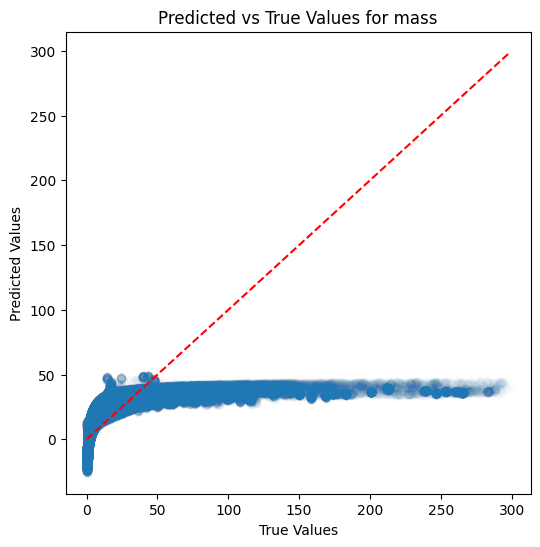

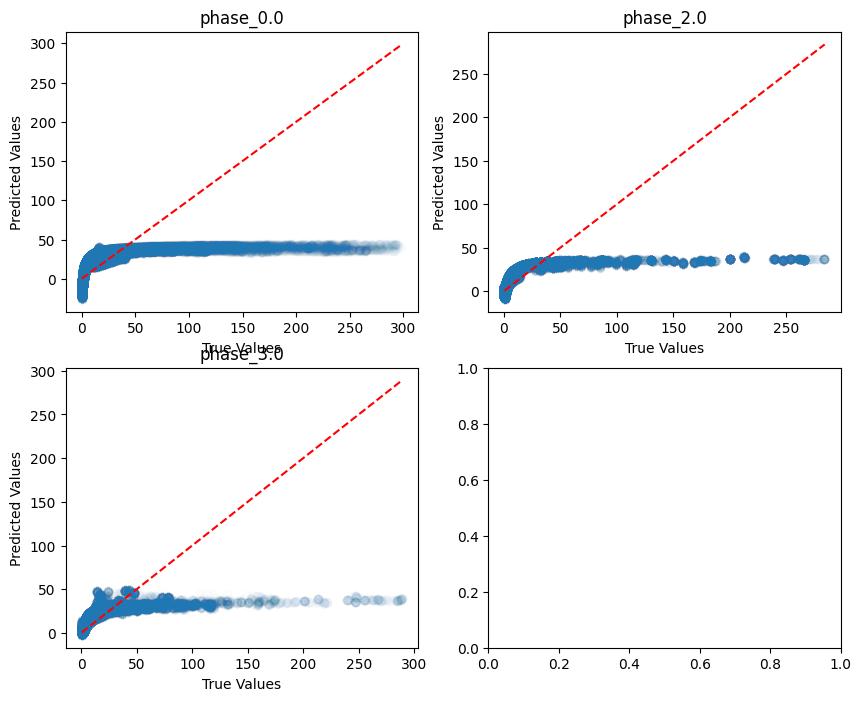

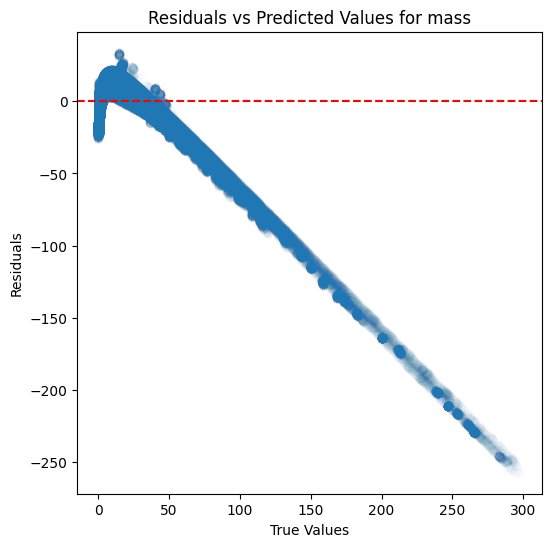

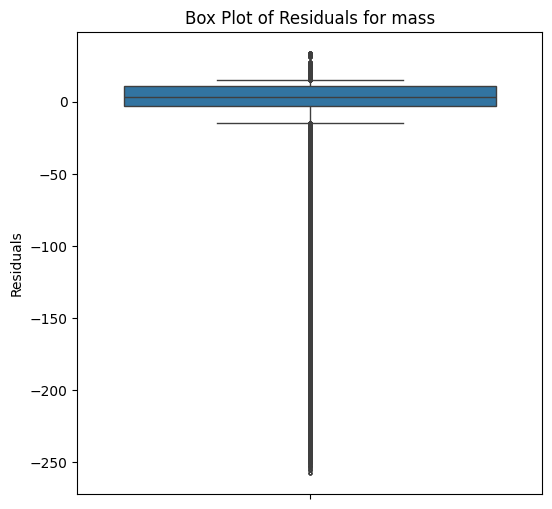

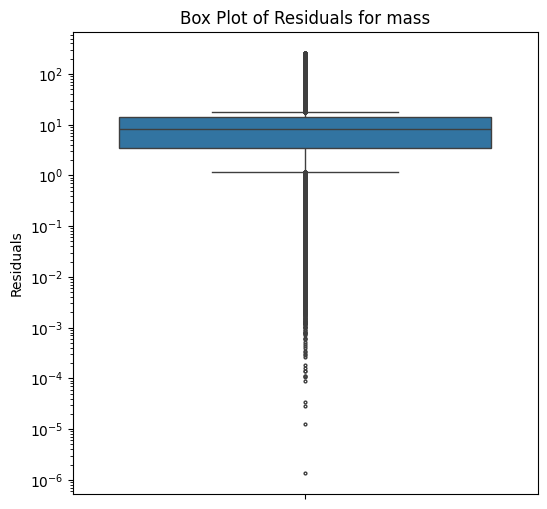

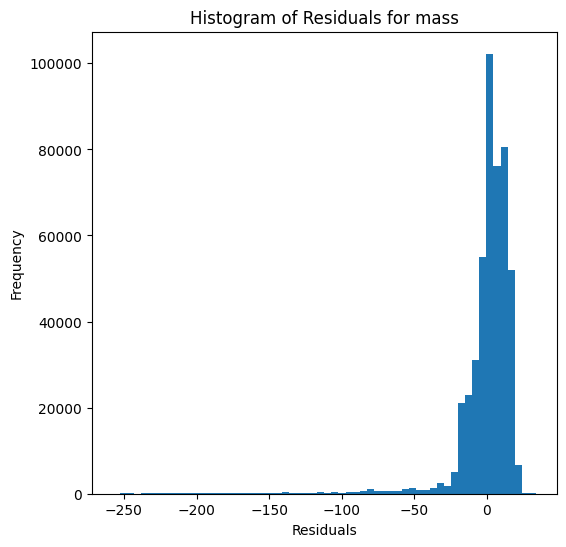

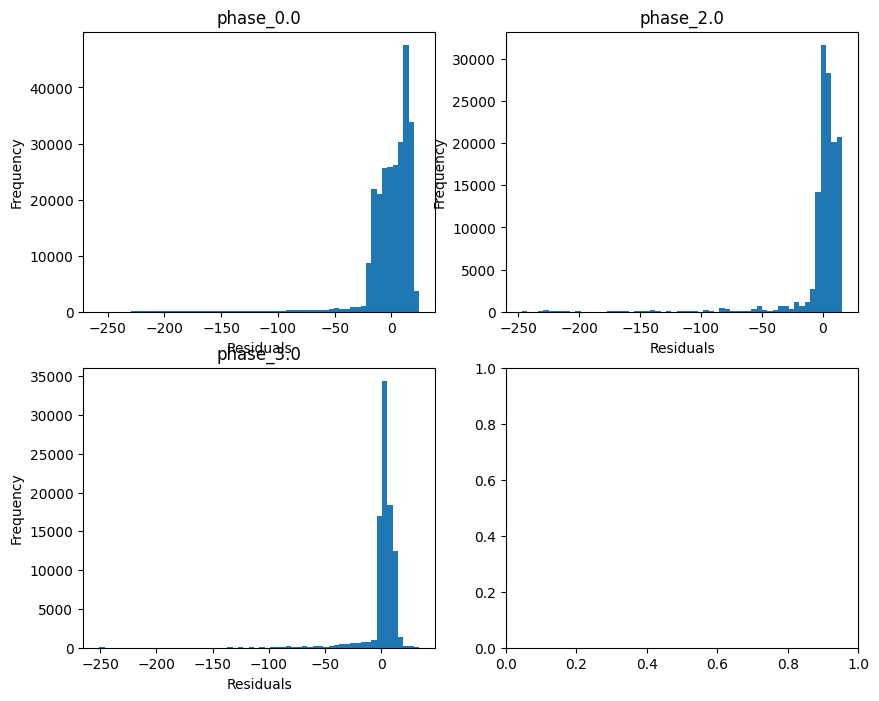

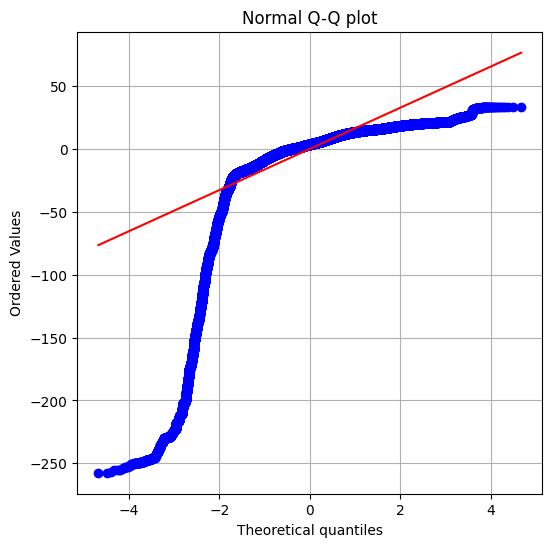

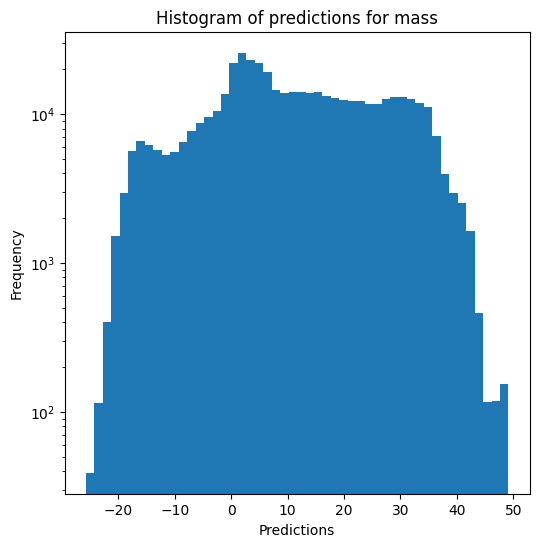

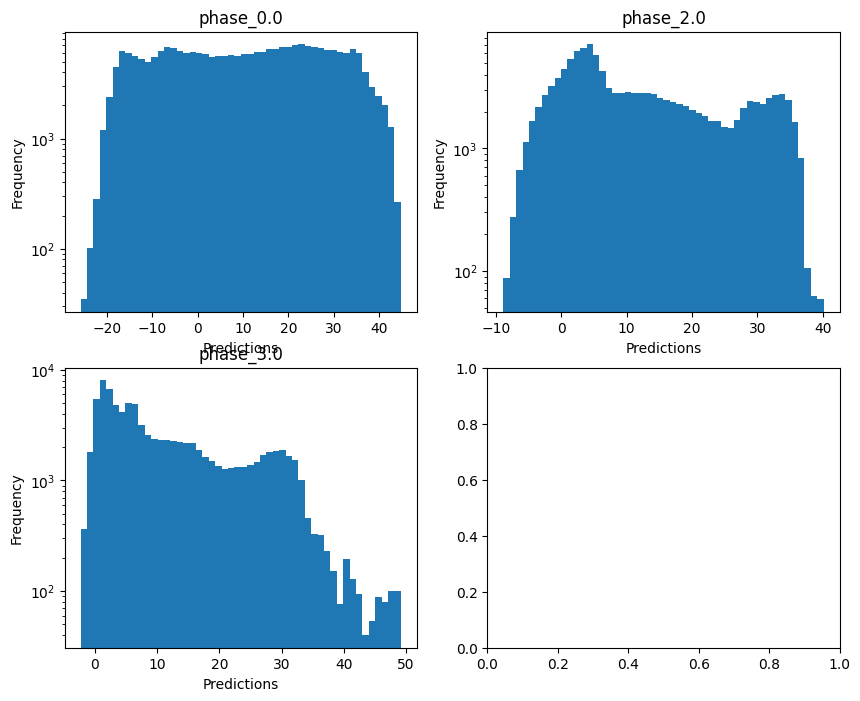

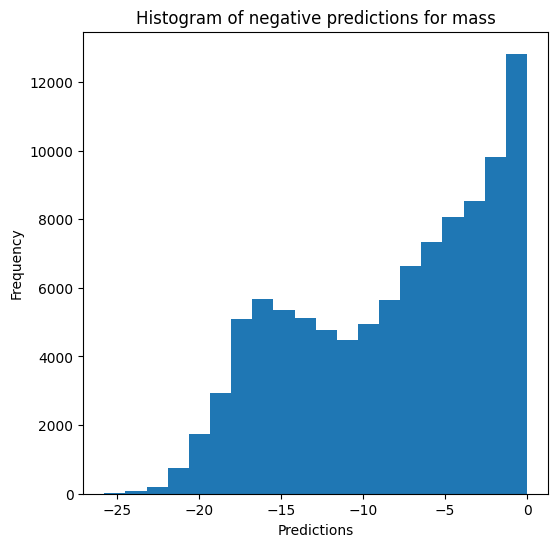


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9778146729622458
  RMSE :  0.08499169455949242
  MAE :  0.06644057676881247
  MedAE :  0.052470644163374436
  CORR :  0.9888944199376599
  MAX_ER :  0.45807766995922083
  Percentiles : 
    75th percentile :  0.09619903944971864
    90th percentile :  0.13469965074636725
    95th percentile :  0.15727958575246567
    99th percentile :  0.2505204276476863

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.891706235288321
  RVE :  0.9679744997103377
  RMSE :  0.0884158297132134
  MAE :  0.057736628688100165
  MedAE :  0.03394437787640836
  CORR :  0.9838665758685889
  MAX_ER :  0.452908397569574
  Percentiles : 
    75th percentile :  0.07349899037494612
    90th percentile :  0.14129835891614495
    95th percentile :  0.19408078671043355
    99th percentile :  0.35002097849302344

radius results for the phase cate

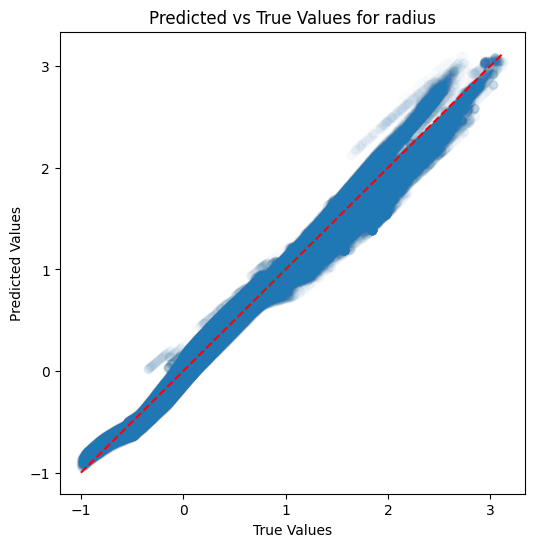

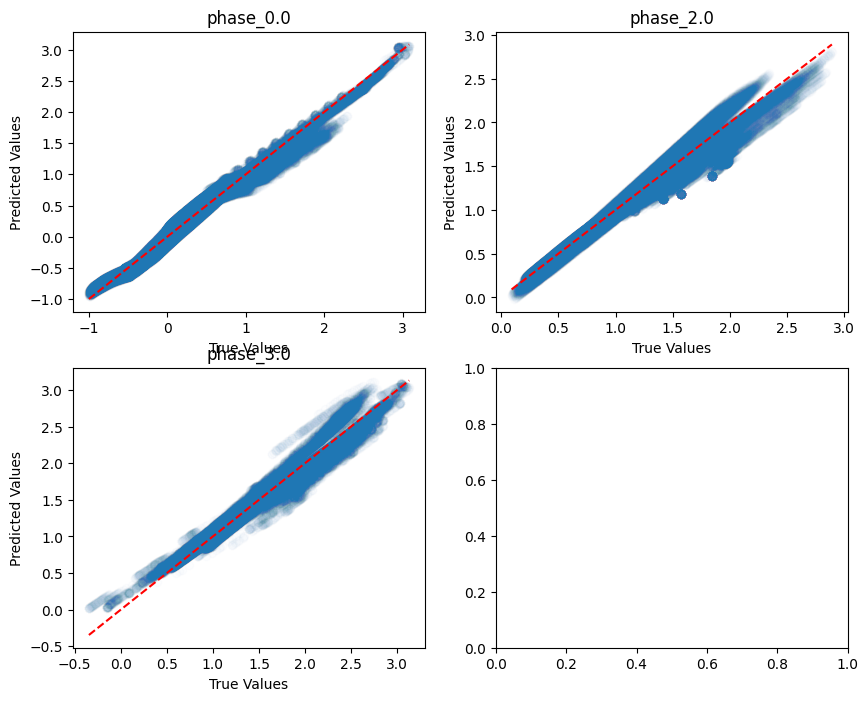

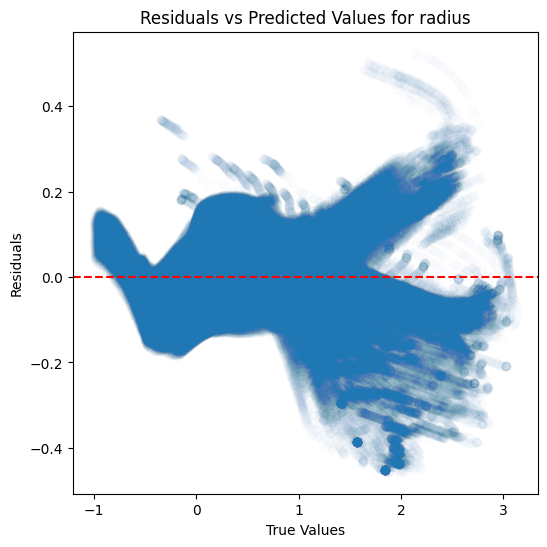

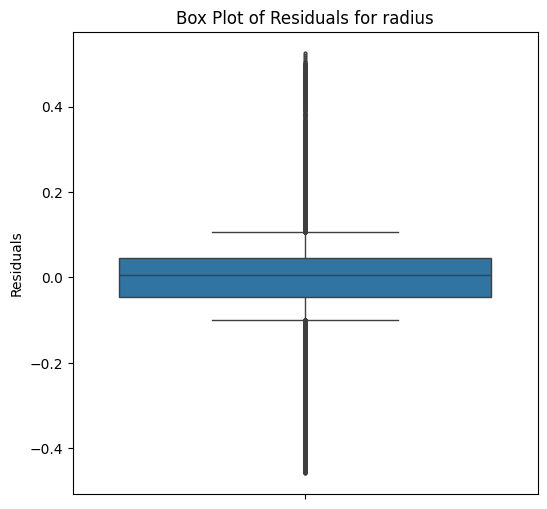

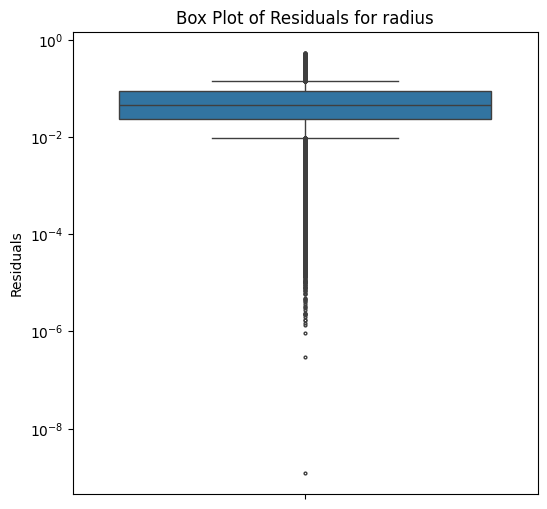

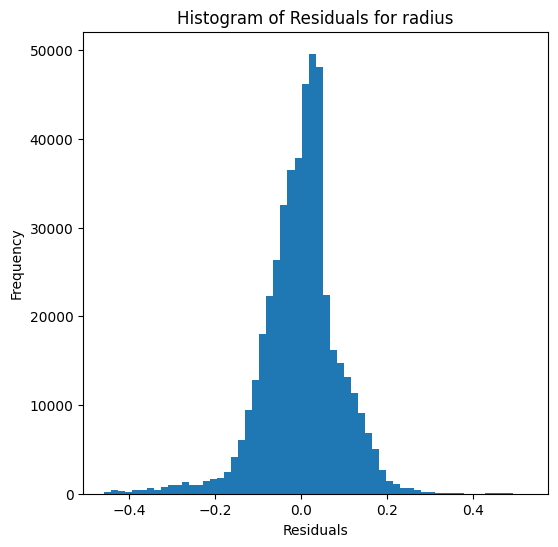

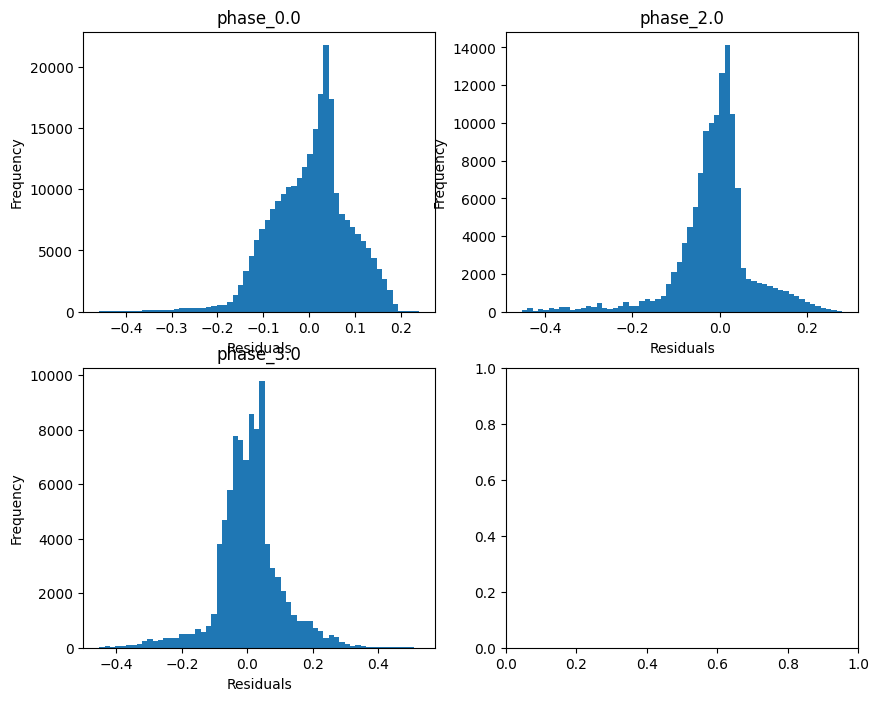

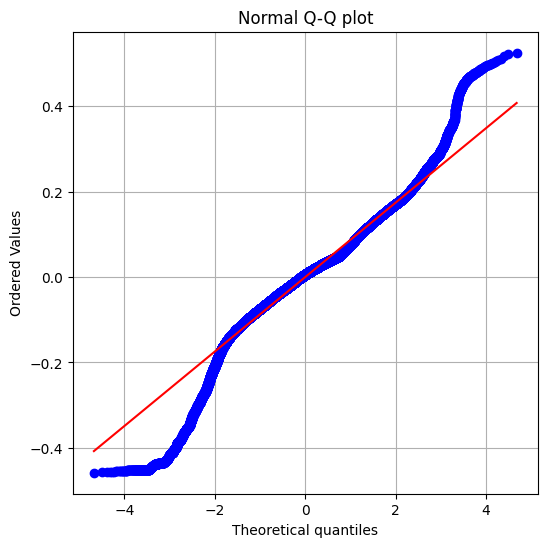

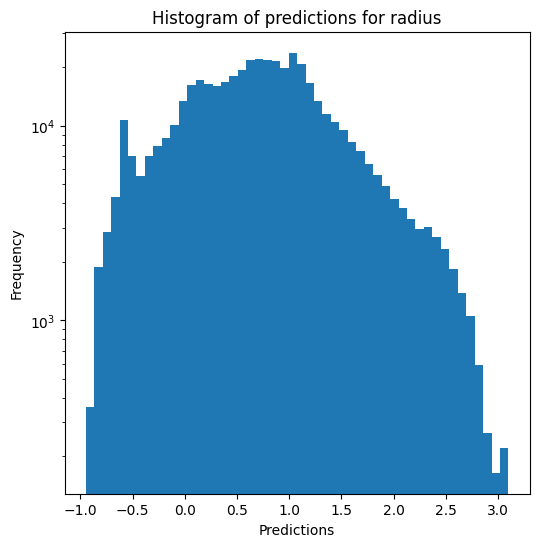

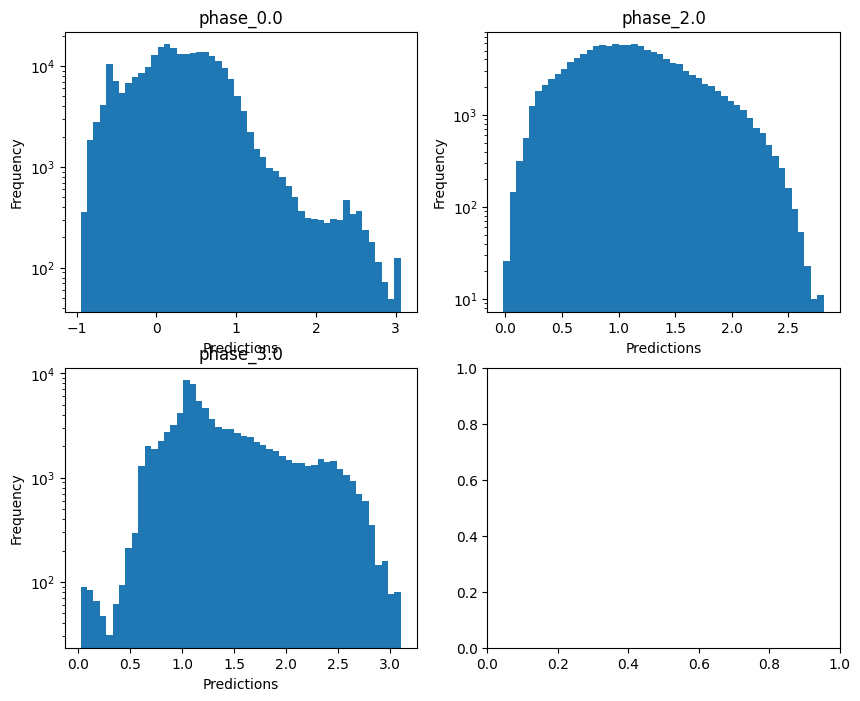

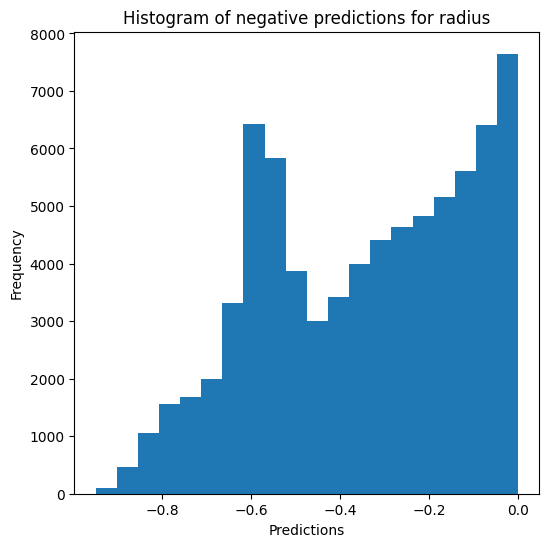

Saving results...


In [9]:
lr_evaluator.evaluate_Kfold_results(LinearRegression, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=False, use_preds=True, save=True, show=True) #, override=True, use_preds=False)

### Decision tree

In [10]:
dt_evaluator = Model_evaluator("decision_tree", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


Base train data :
Evaluating predictions...
no negative values

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 298.5447575808816
  RVE :  0.9935567994940296
  RMSE :  2.111164723262909
  MAE :  0.26982874335994456
  MedAE :  0.0059165484966978155
  CORR :  0.9967888598703755
  MAX_ER :  131.77529017024463
  Percentiles : 
    75th percentile :  0.03085906559757101
    90th percentile :  0.18471893331708558
    95th percentile :  0.6702916148205814
    99th percentile :  5.918016893582675

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 283.72102985530483
  RVE :  0.9991682912199935
  RMSE :  0.8563821878406251
  MAE :  0.06250788141530114
  MedAE :  0.00035448824774864107
  CORR :  0.9995841526922911
  MAX_ER :  115.07406668861114
  Percentiles : 
    75th percentile :  0.00549881642971789
    90th percentile :  0.025495499623657915
    95th percentile :  0.04576150365672606
    99th percentil

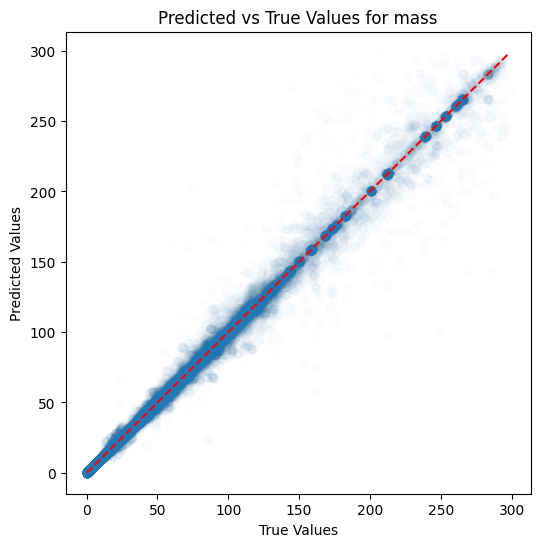

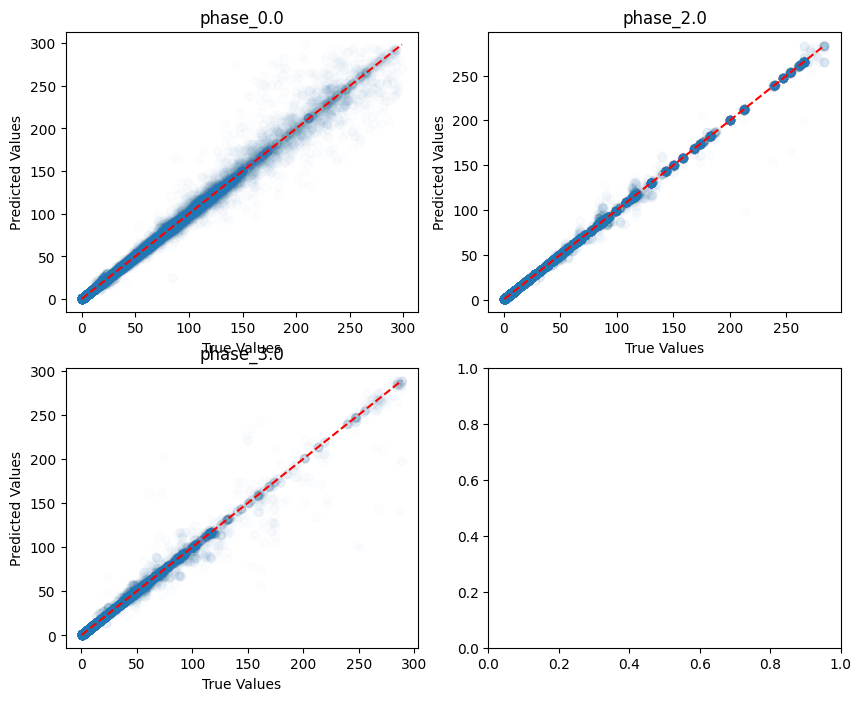

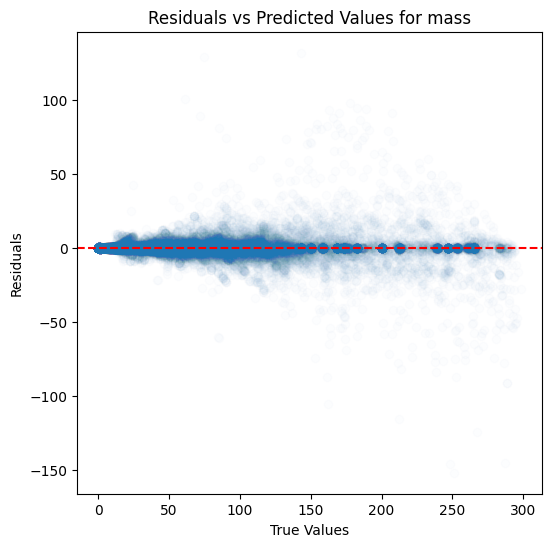

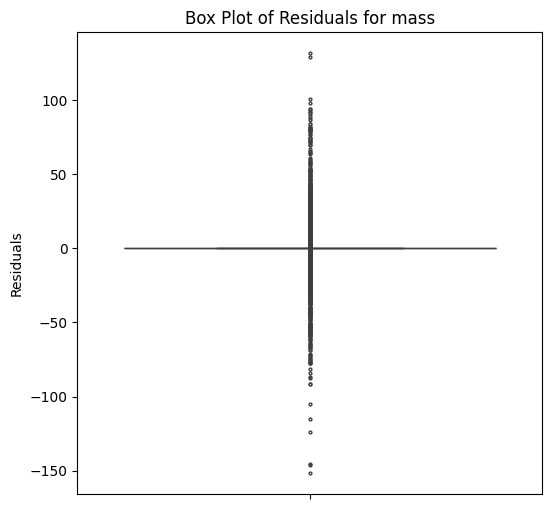

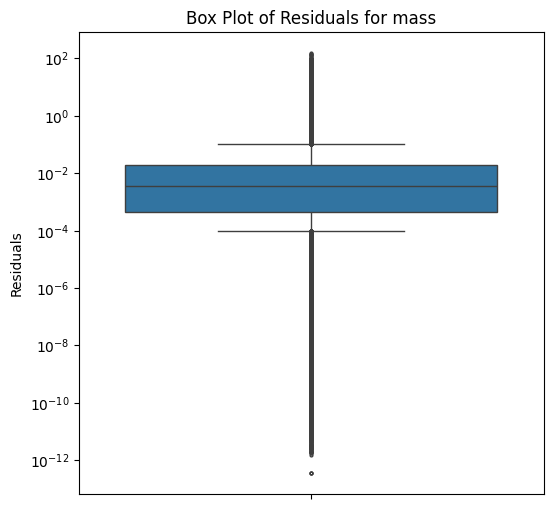

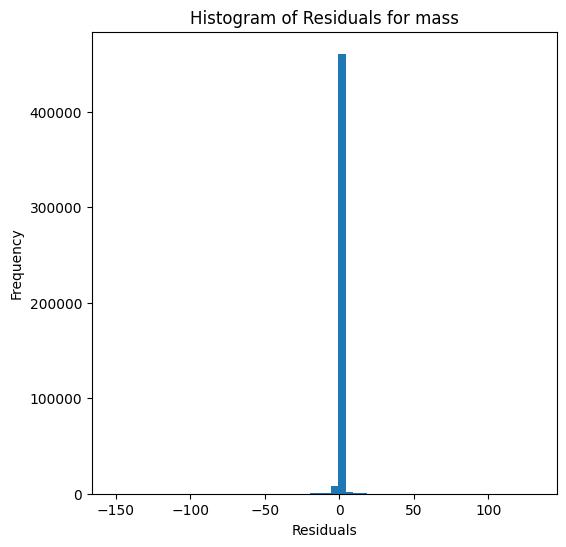

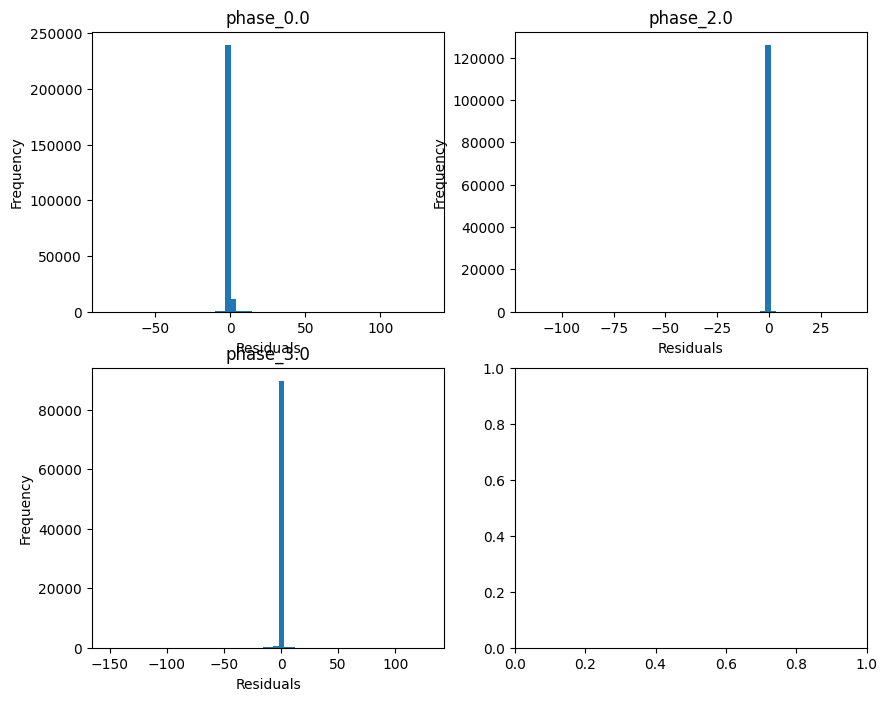

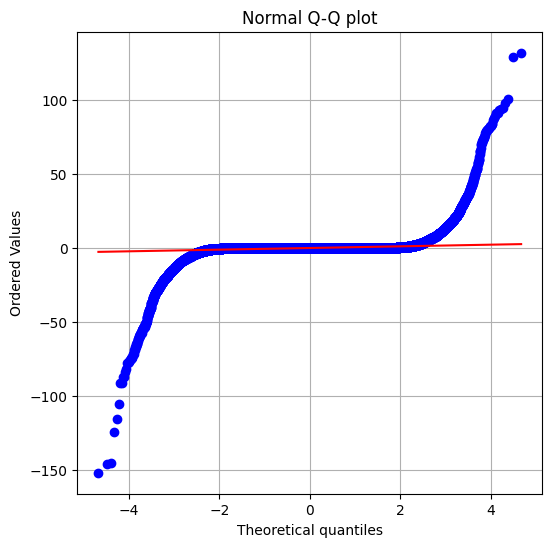

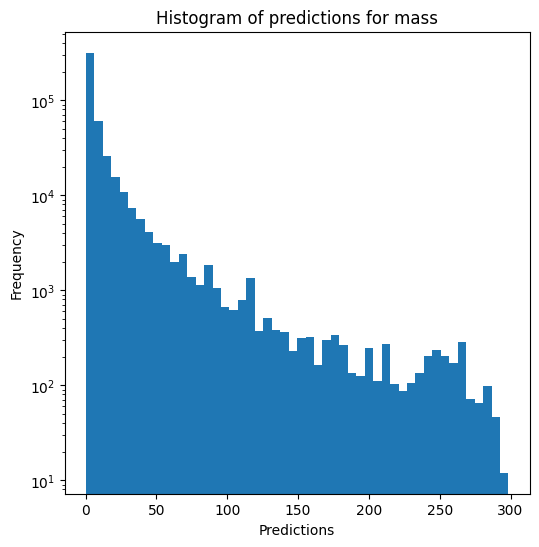

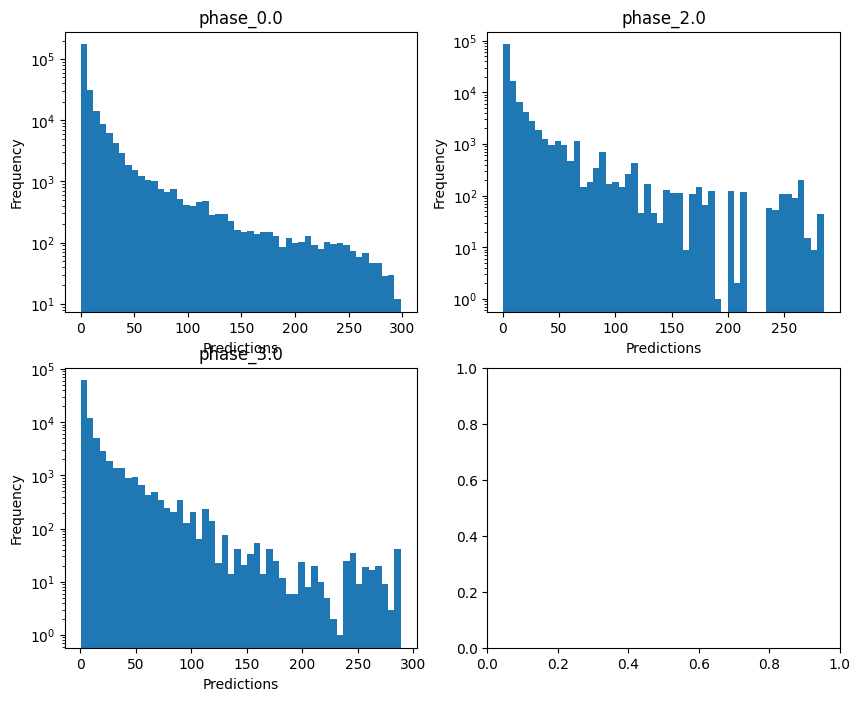


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9997813864623402
  RMSE :  0.008432798419293872
  MAE :  0.0046079124125086406
  MedAE :  0.0026266103180270783
  CORR :  0.9998907289180995
  MAX_ER :  0.48792609242004326
  Percentiles : 
    75th percentile :  0.0053497743308552614
    90th percentile :  0.010306007864542038
    95th percentile :  0.015168922562012247
    99th percentile :  0.03230981279077209

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.891706235288321
  RVE :  0.999593711552545
  RMSE :  0.009900249628448179
  MAE :  0.006758572225259206
  MedAE :  0.005226559279315257
  CORR :  0.9997981364006748
  MAX_ER :  0.2623505527794312
  Percentiles : 
    75th percentile :  0.009073251387631653
    90th percentile :  0.013478144895161704
    95th percentile :  0.016687082930794215
    99th percentile :  0.03211824034333693

radius results for

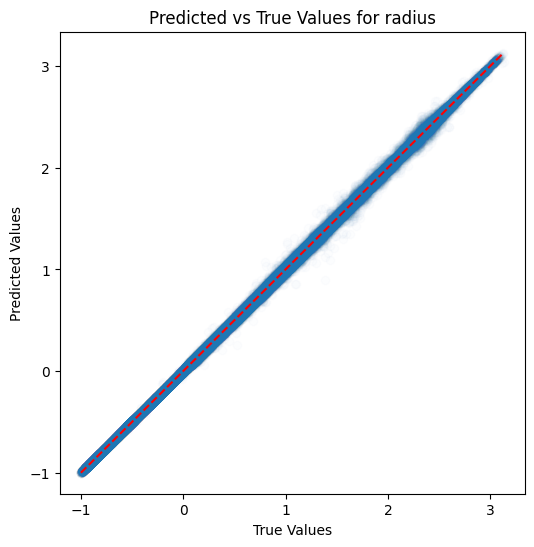

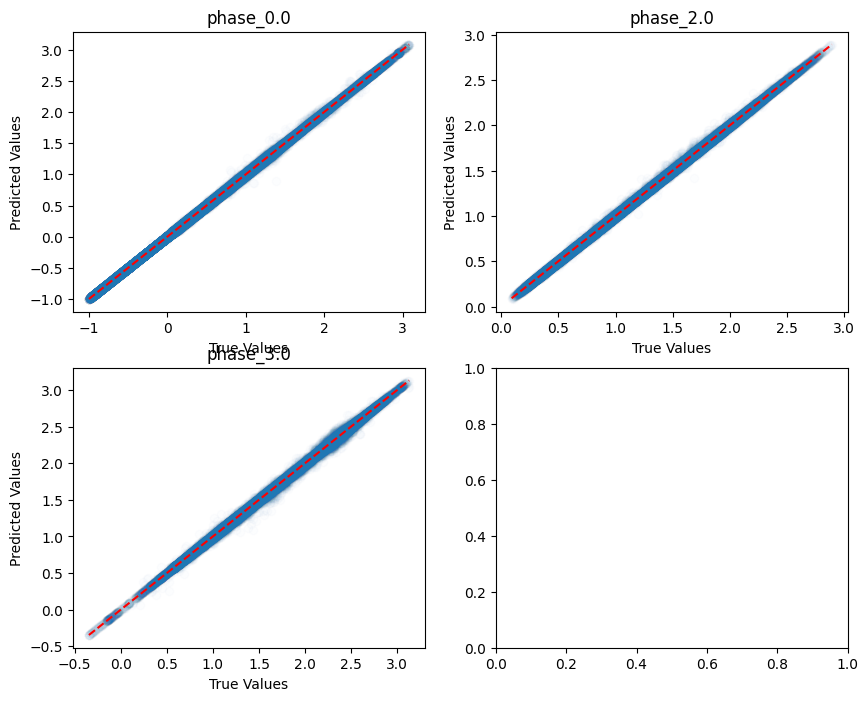

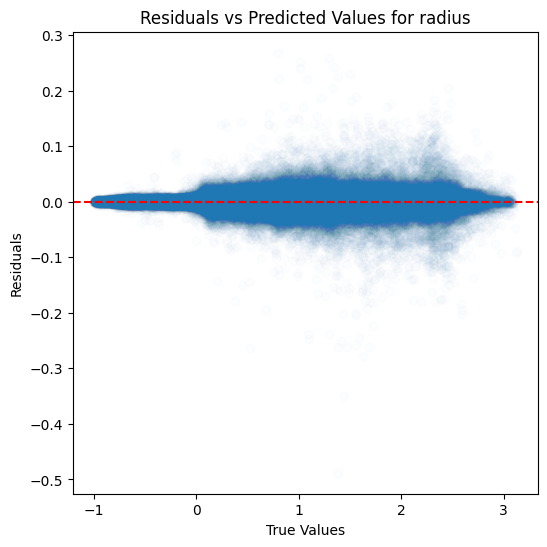

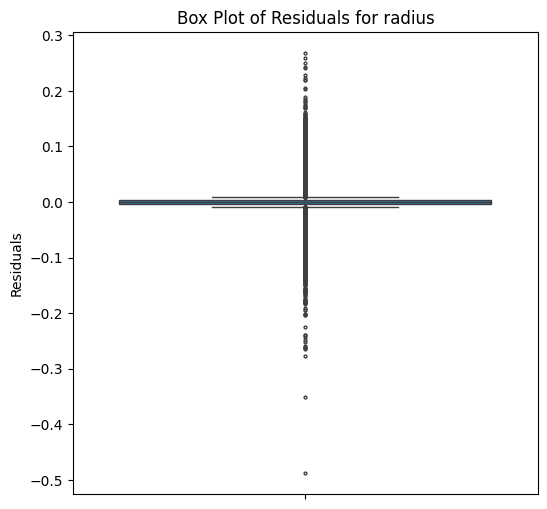

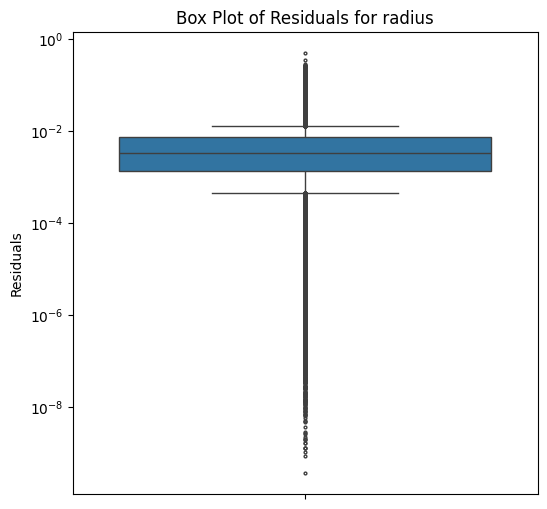

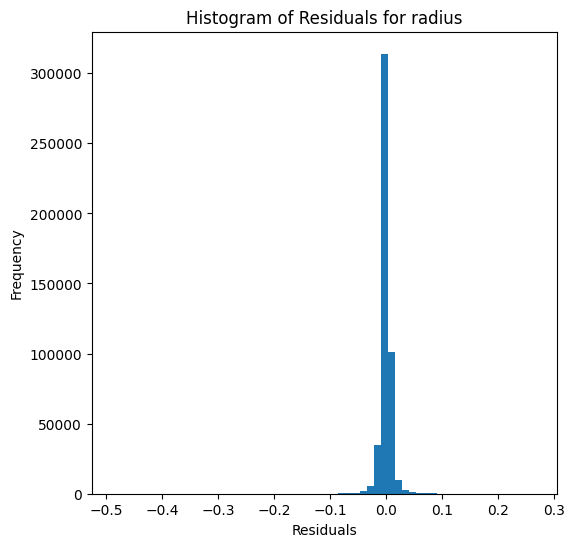

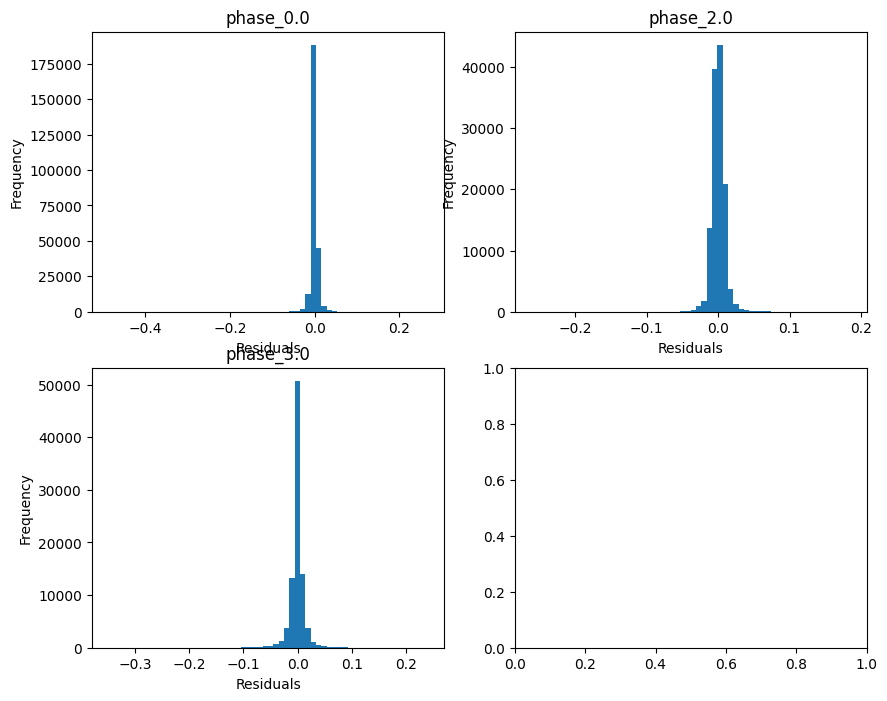

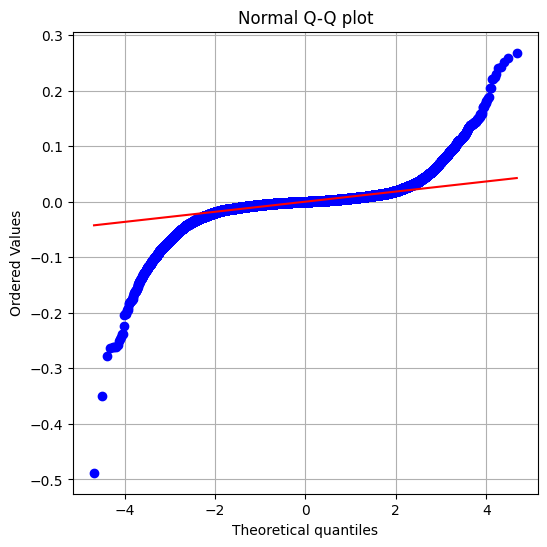

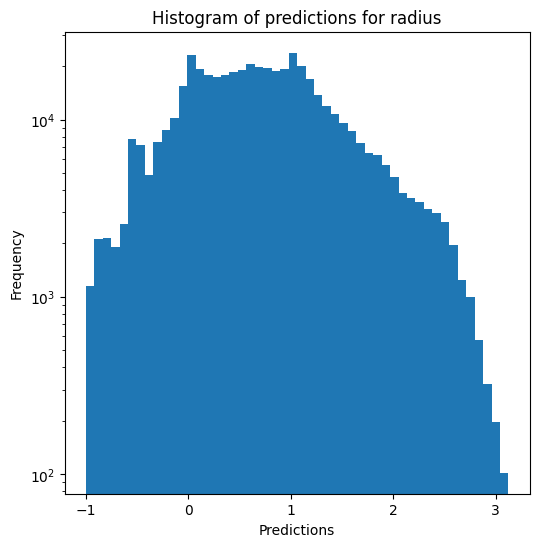

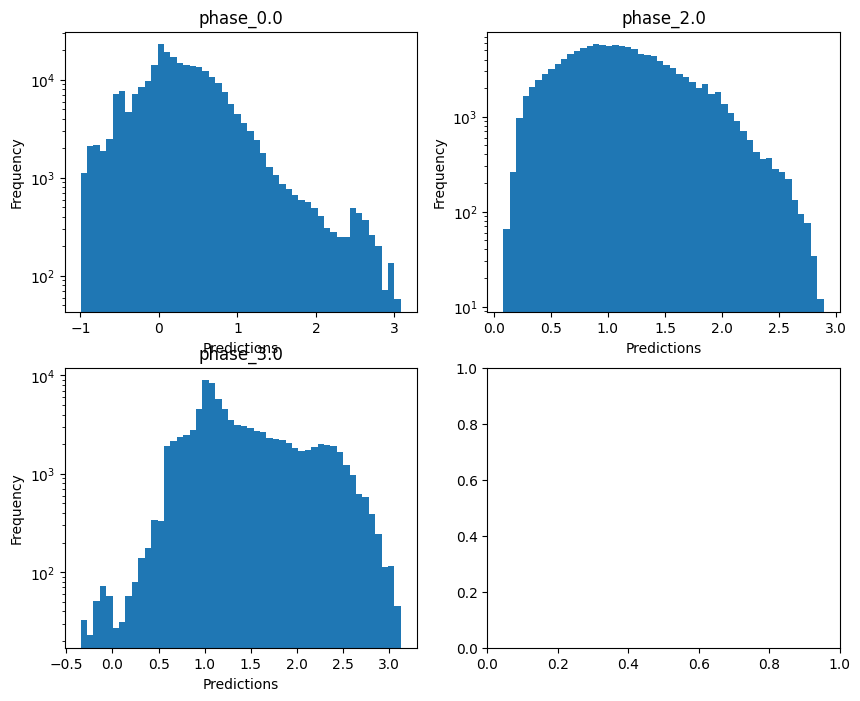

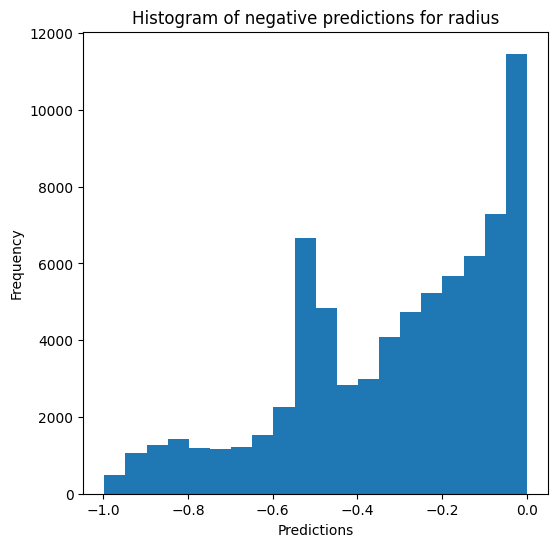

Saving results...


In [11]:
dt_evaluator.evaluate_Kfold_results(DecisionTreeRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=False, use_preds=True, save=True, show=True)

### K-nearest neighbours

In [12]:
knn_evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


Base train data :
Evaluating predictions...
no negative values

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 298.5447575808816
  RVE :  0.9843387655163102
  RMSE :  3.292362185047644
  MAE :  0.4317822333077811
  MedAE :  0.010309898110725357
  CORR :  0.9924111983284241
  MAX_ER :  126.67441415982648
  Percentiles : 
    75th percentile :  0.05187255440003935
    90th percentile :  0.33456343769282815
    95th percentile :  1.0302260826357286
    99th percentile :  8.942648085934486

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 283.72102985530483
  RVE :  0.9993836364150782
  RMSE :  0.7372507757129543
  MAE :  0.09538418274204148
  MedAE :  0.003644066674525215
  CORR :  0.9996927065174758
  MAX_ER :  37.48661252169403
  Percentiles : 
    75th percentile :  0.01708344572699827
    90th percentile :  0.07857928736632087
    95th percentile :  0.1618304217730987
    99th percentile :  2.

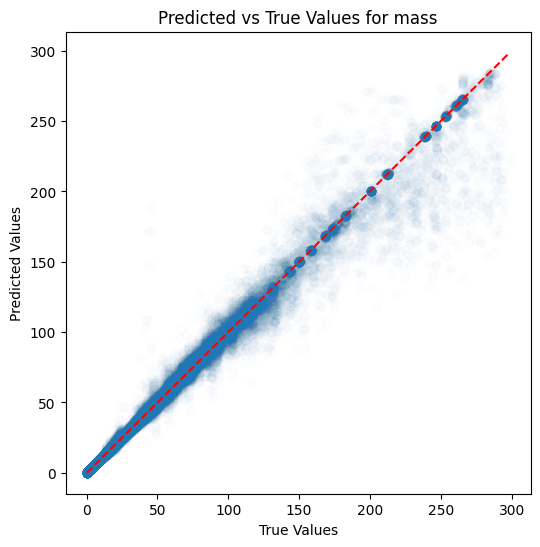

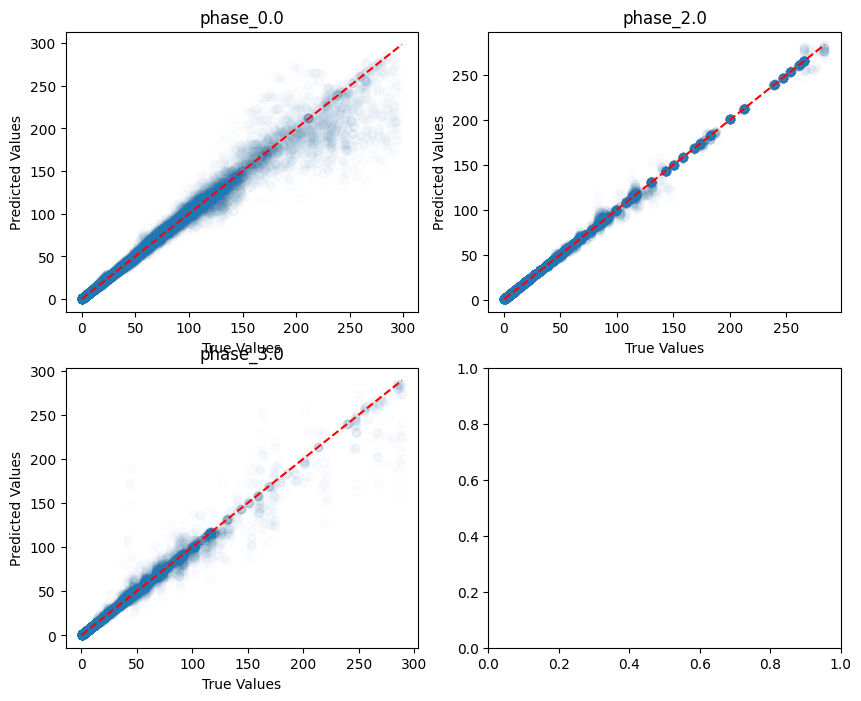

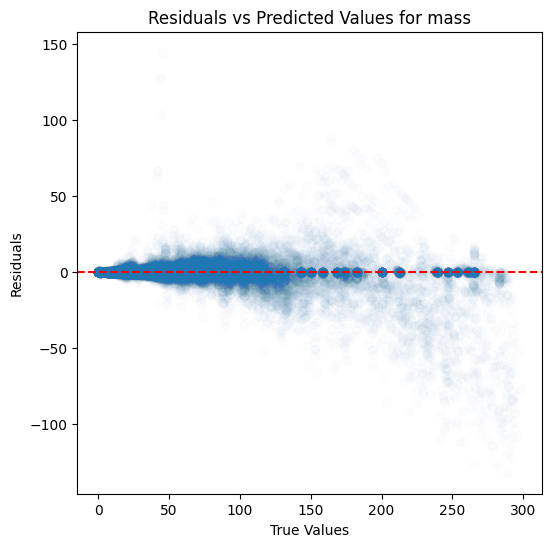

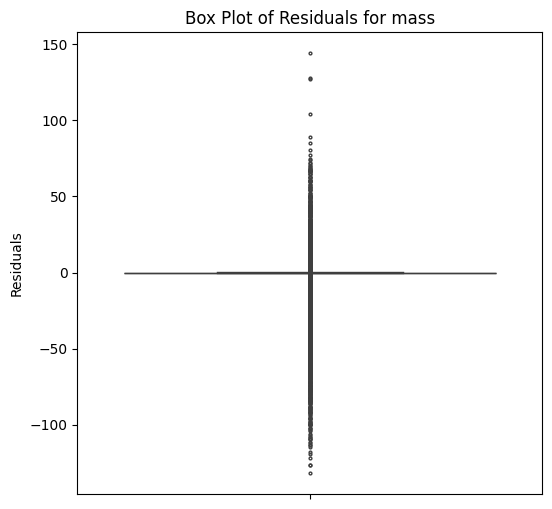

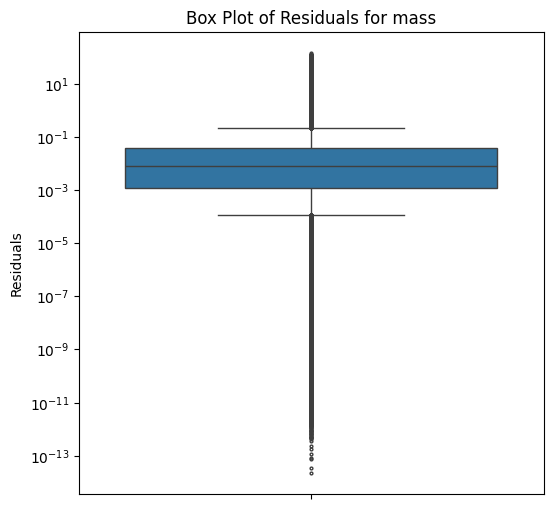

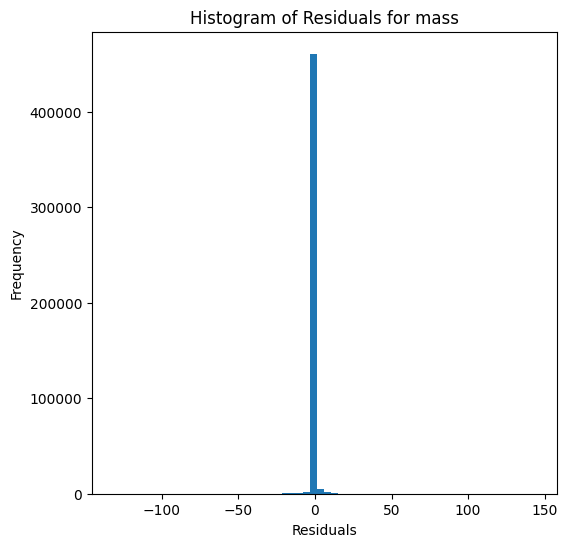

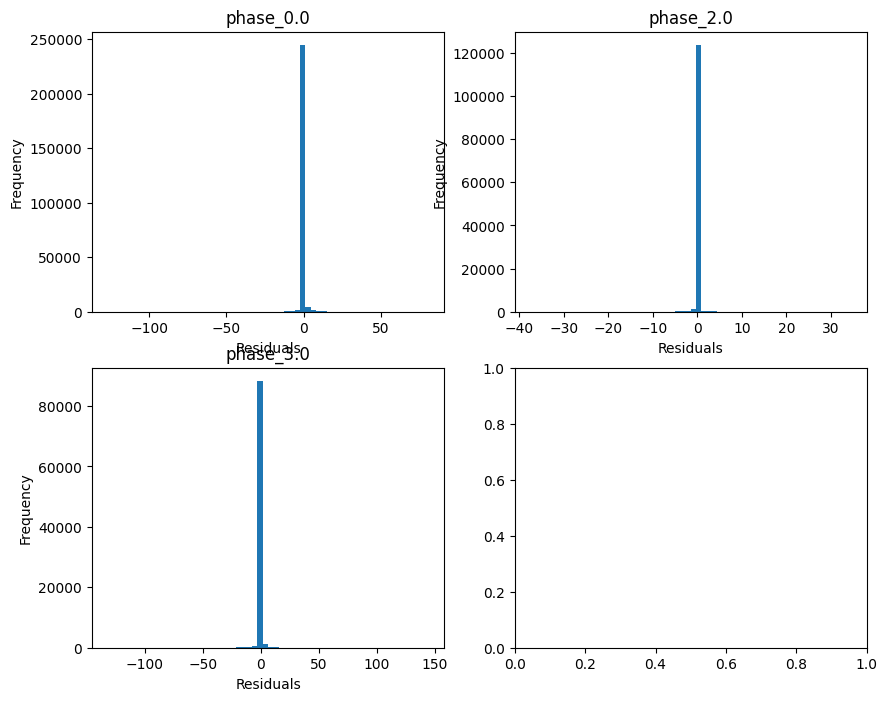

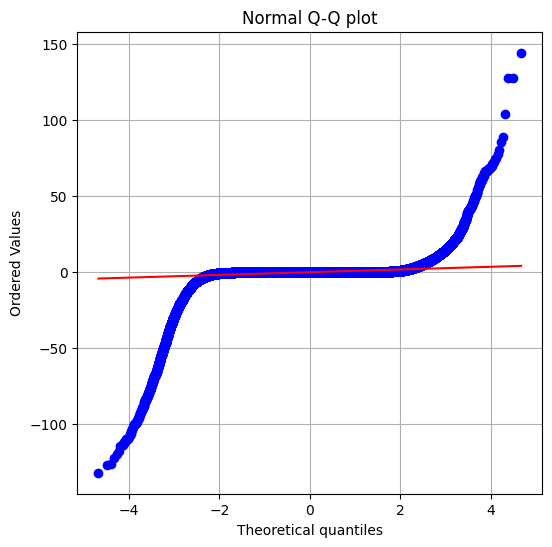

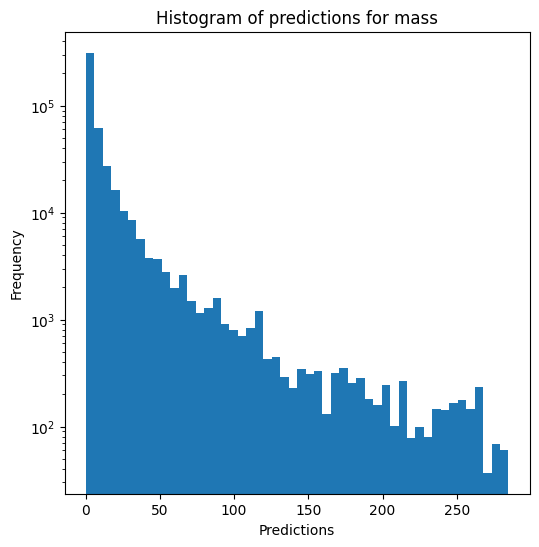

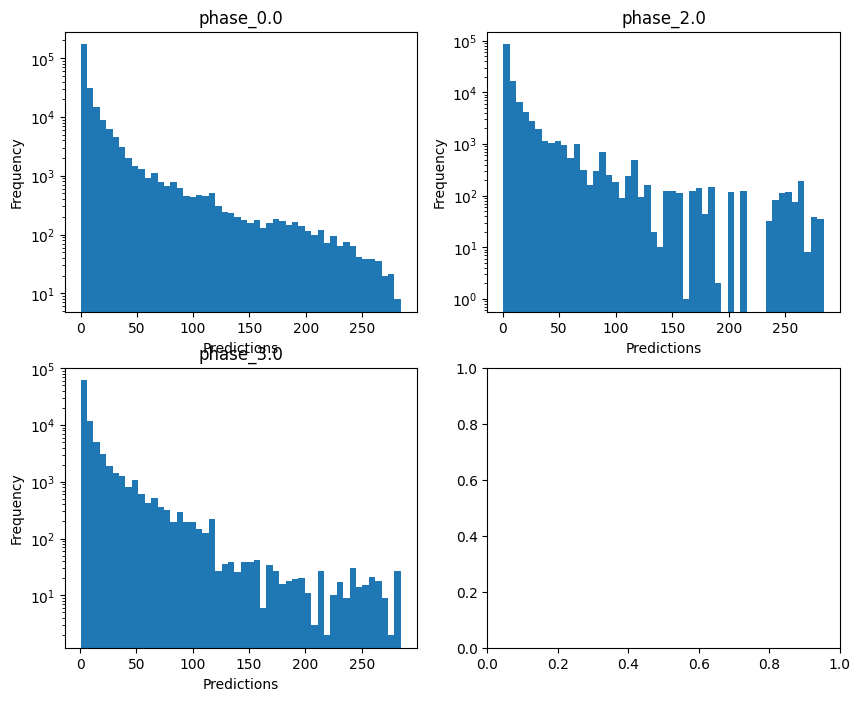


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9998333563537635
  RMSE :  0.007362583562507818
  MAE :  0.004268976716445437
  MedAE :  0.002587315638011012
  CORR :  0.9999169942116342
  MAX_ER :  0.1541932825054977
  Percentiles : 
    75th percentile :  0.00518315713484023
    90th percentile :  0.009551796207118502
    95th percentile :  0.013550120941980666
    99th percentile :  0.02639653929001715

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.891706235288321
  RVE :  0.9999055166815642
  RMSE :  0.004771005490760497
  MAE :  0.0034537346530787026
  MedAE :  0.0025434069250853675
  CORR :  0.9999527572442021
  MAX_ER :  0.07723242145030396
  Percentiles : 
    75th percentile :  0.004691856845975062
    90th percentile :  0.0077227474516430306
    95th percentile :  0.009780350181265789
    99th percentile :  0.014525614812519533

radius results fo

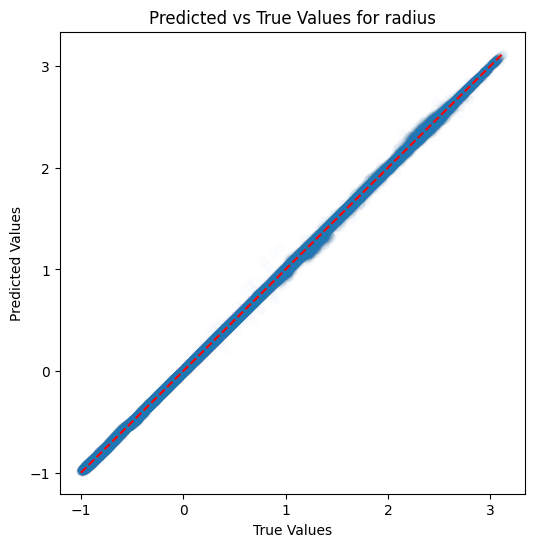

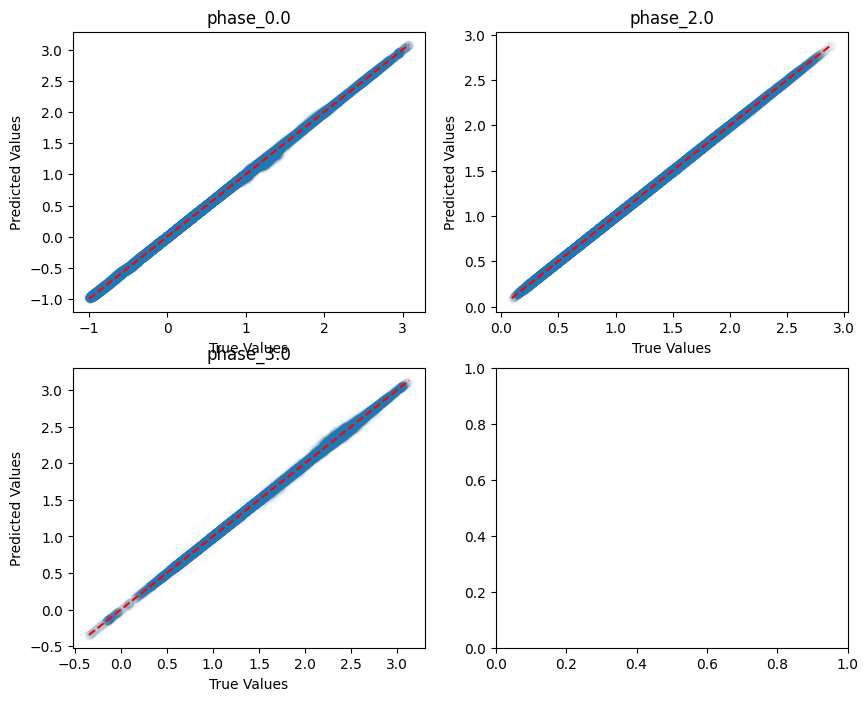

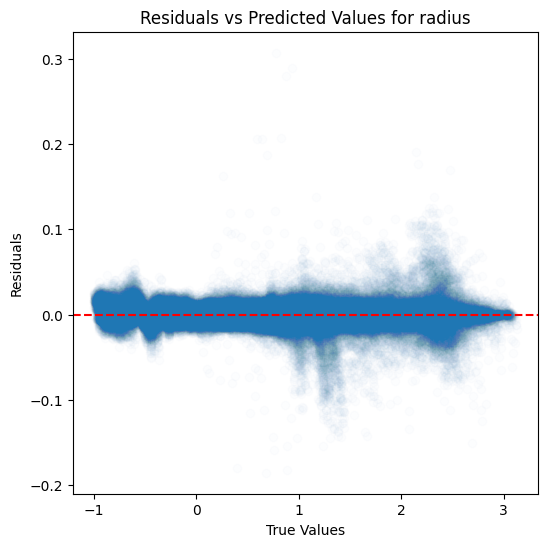

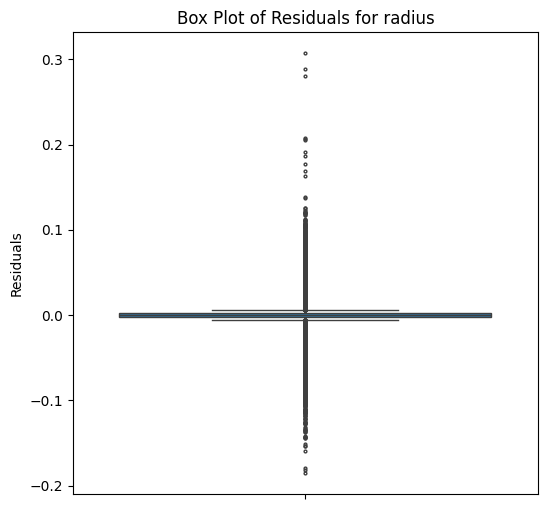

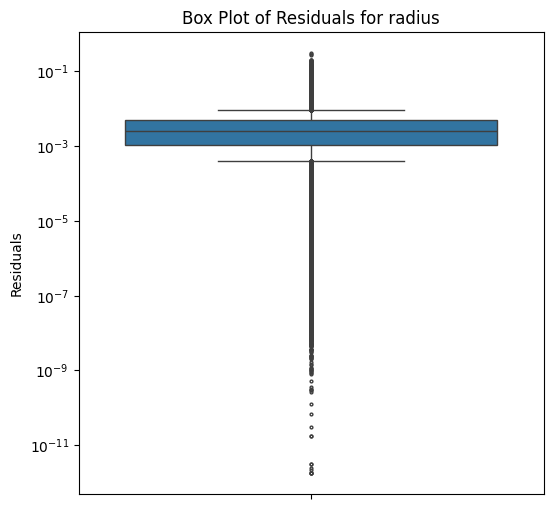

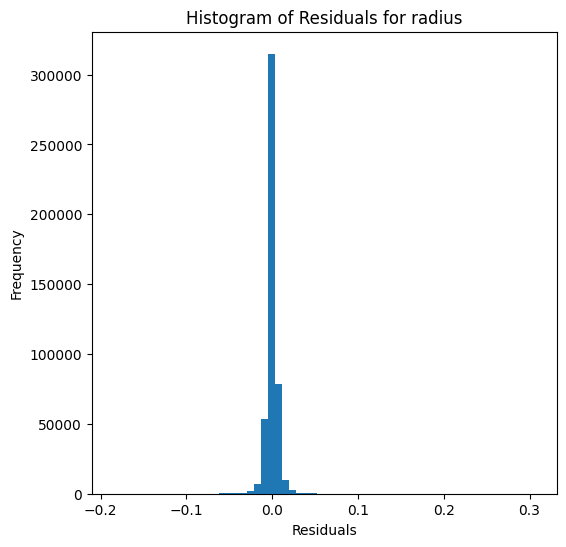

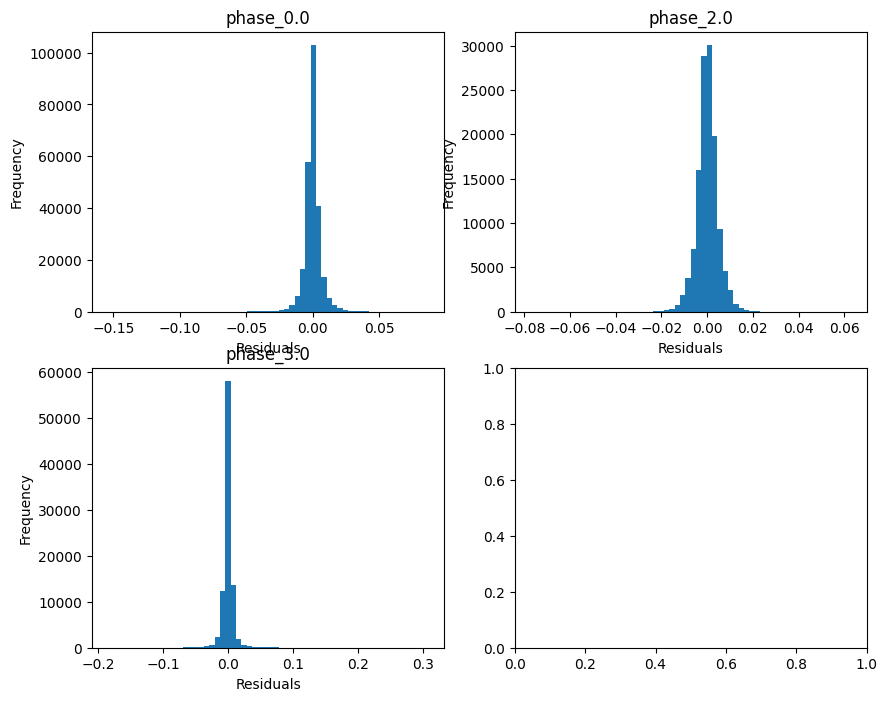

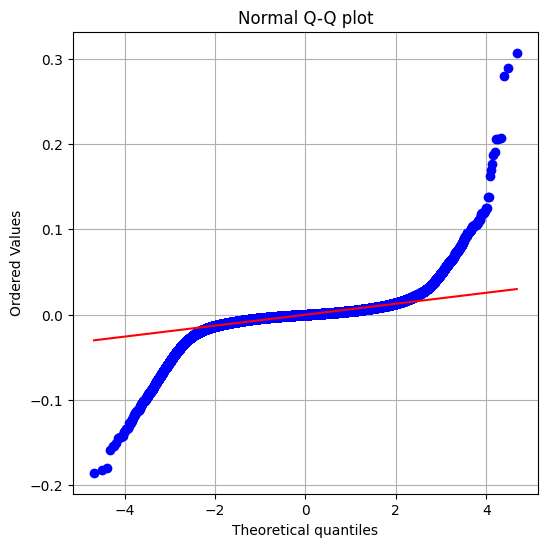

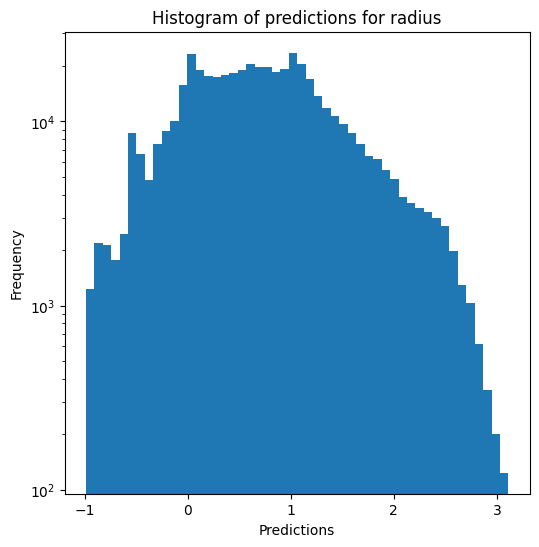

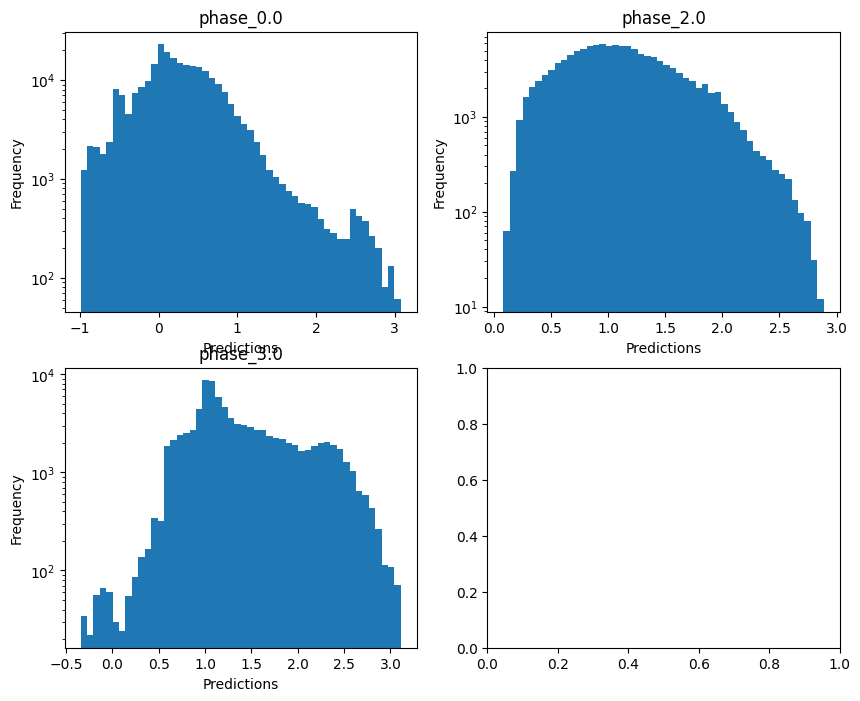

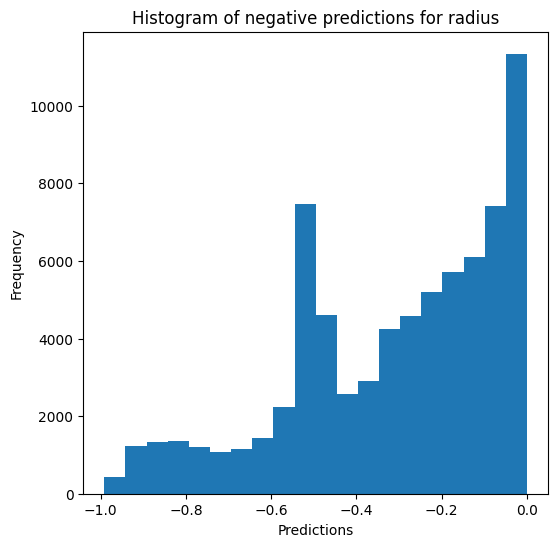

Saving results...


In [13]:
knn_evaluator.evaluate_Kfold_results(KNeighborsRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=False, use_preds=True, save=True, show=True)

### Random forests

In [14]:
rf_evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


Base train data :
Evaluating predictions...
no negative values

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 298.5447575808816
  RVE :  0.9973575906750899
  RMSE :  1.3521665845754873
  MAE :  0.16783299547779296
  MedAE :  0.0035490560629605206
  CORR :  0.9986793327165373
  MAX_ER :  83.61091180145692
  Percentiles : 
    75th percentile :  0.01627090845797008
    90th percentile :  0.10845675544511305
    95th percentile :  0.4167769360033529
    99th percentile :  3.6048027617715754

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 283.72102985530483
  RVE :  0.9997441818803499
  RMSE :  0.47498420224835197
  MAE :  0.05965777535357753
  MedAE :  0.004034495488792533
  CORR :  0.9998728077084751
  MAX_ER :  21.388650133880788
  Percentiles : 
    75th percentile :  0.010637460583327762
    90th percentile :  0.025593084093348588
    95th percentile :  0.07213382063133715
    99th percenti

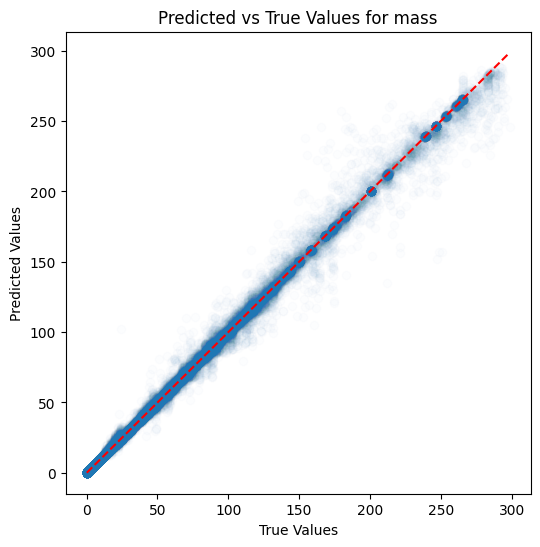

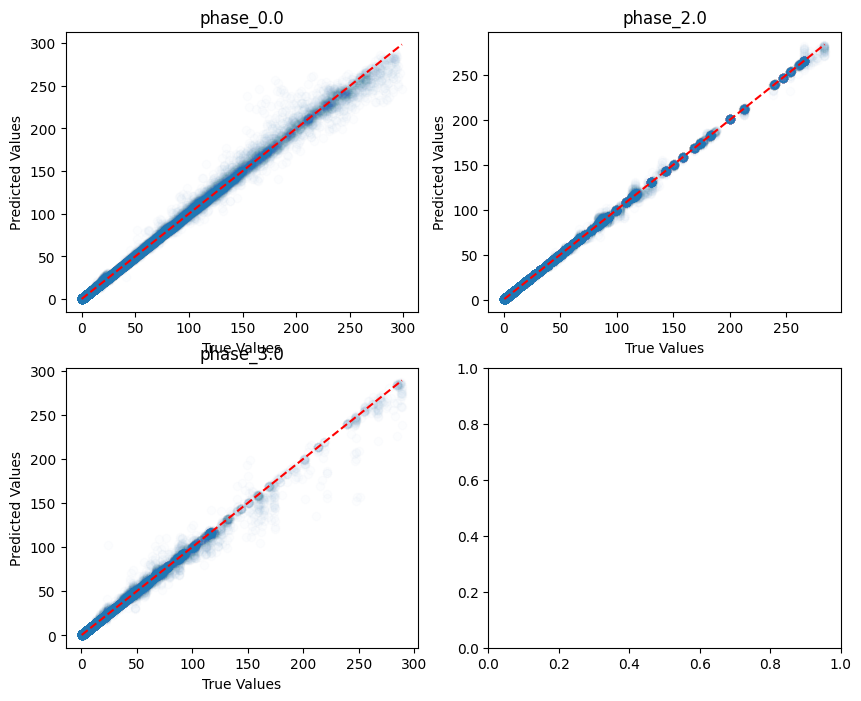

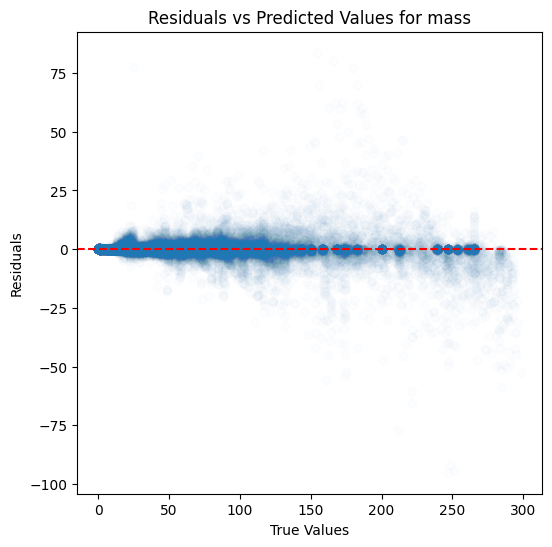

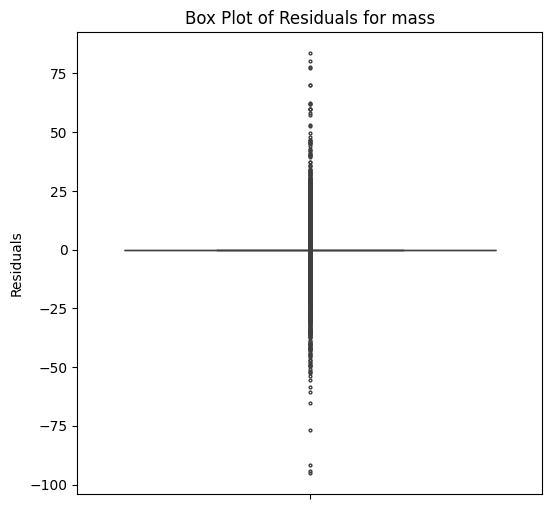

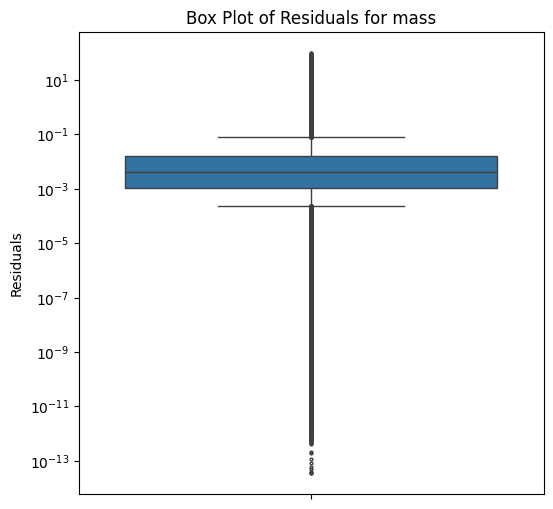

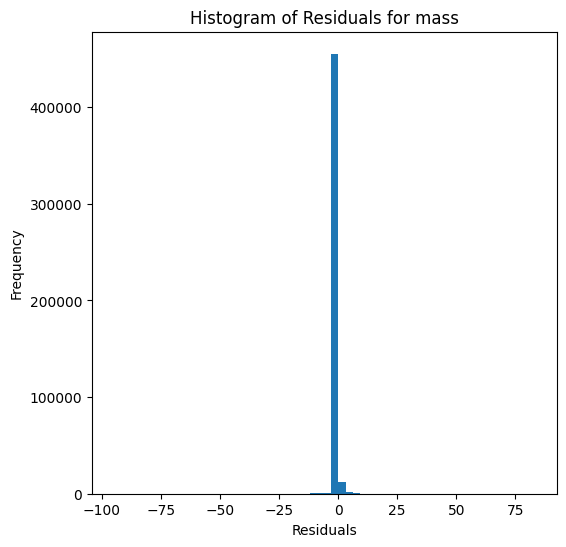

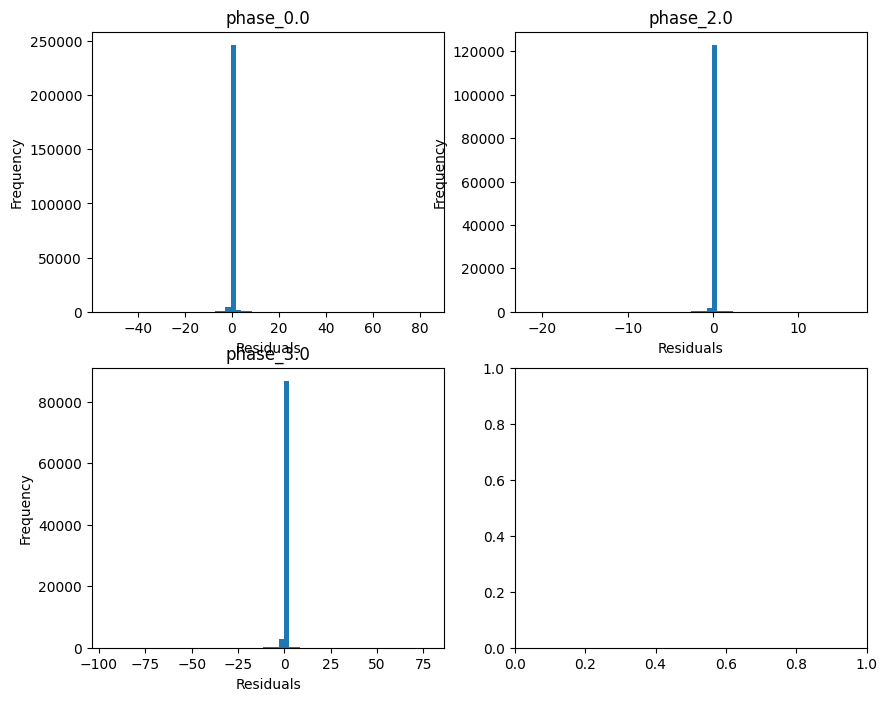

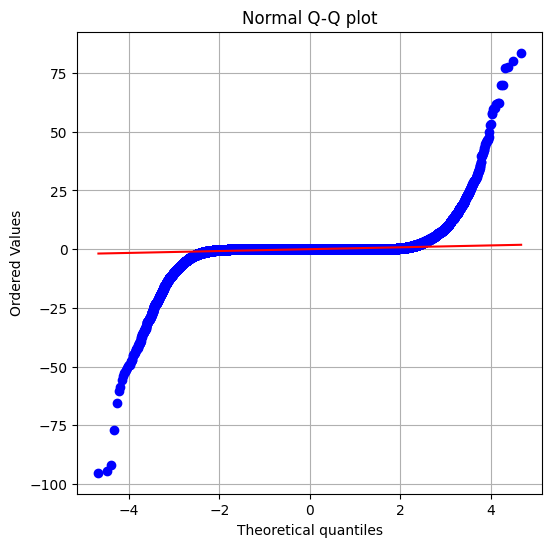

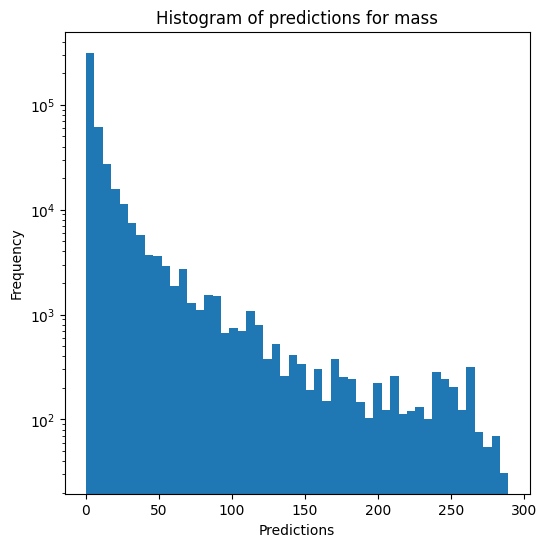

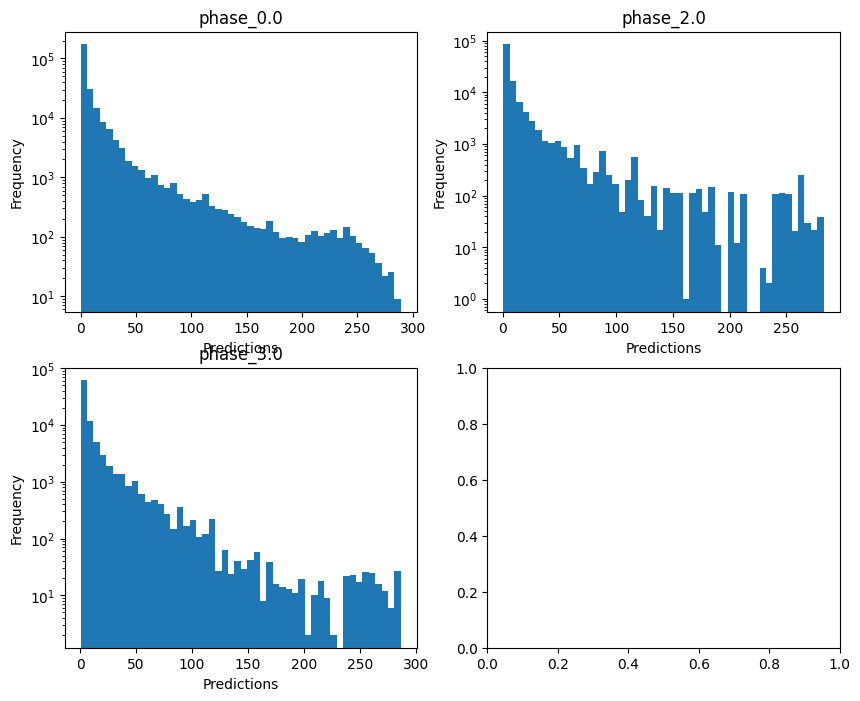


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.999946522209612
  RMSE :  0.004170603729200659
  MAE :  0.002085155955779884
  MedAE :  0.001015737099057168
  CORR :  0.9999733020849314
  MAX_ER :  0.35809277456115796
  Percentiles : 
    75th percentile :  0.002328033076485235
    90th percentile :  0.00484538313615747
    95th percentile :  0.007499591533002214
    99th percentile :  0.016474636713688554

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.891706235288321
  RVE :  0.9999324574753913
  RMSE :  0.0040635793712323195
  MAE :  0.0026899338759270694
  MedAE :  0.001751537279836457
  CORR :  0.9999669085040882
  MAX_ER :  0.10145308941528808
  Percentiles : 
    75th percentile :  0.0035869141594420673
    90th percentile :  0.006190931644824804
    95th percentile :  0.008288300238505979
    99th percentile :  0.014179516064144155

radius results f

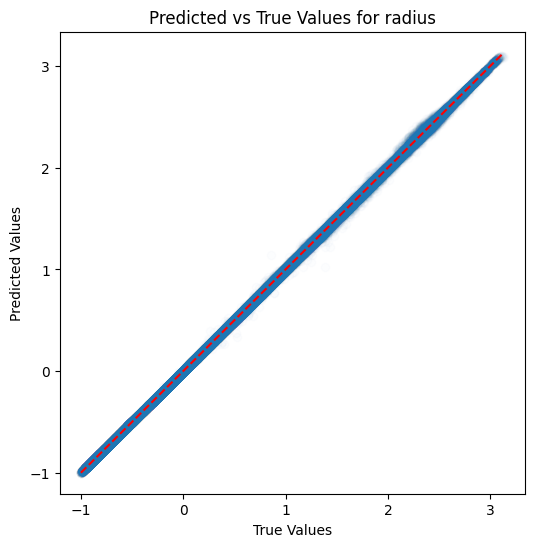

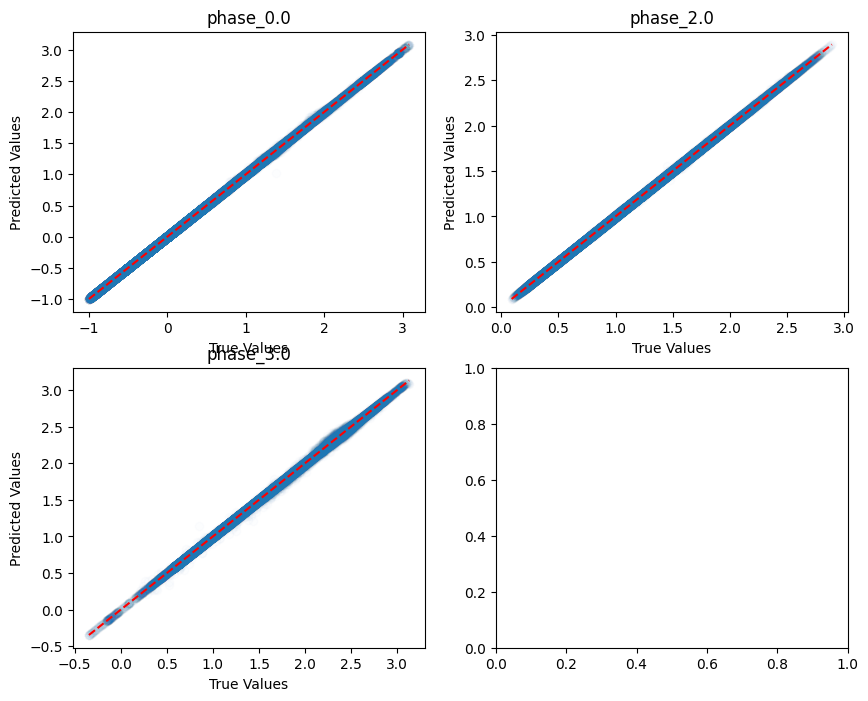

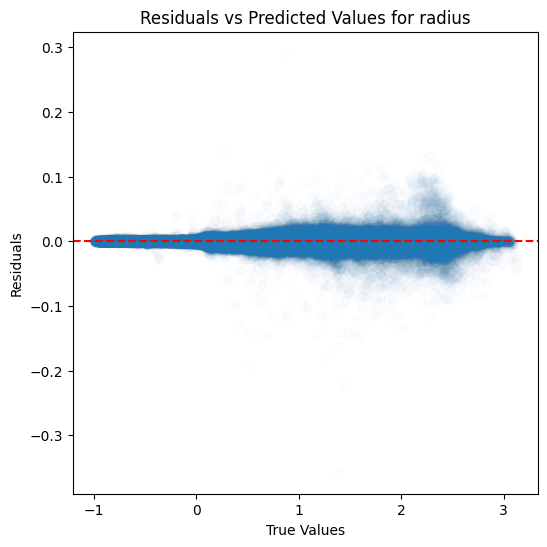

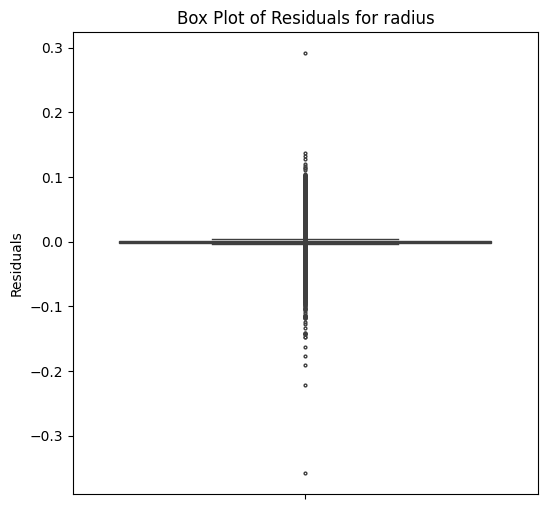

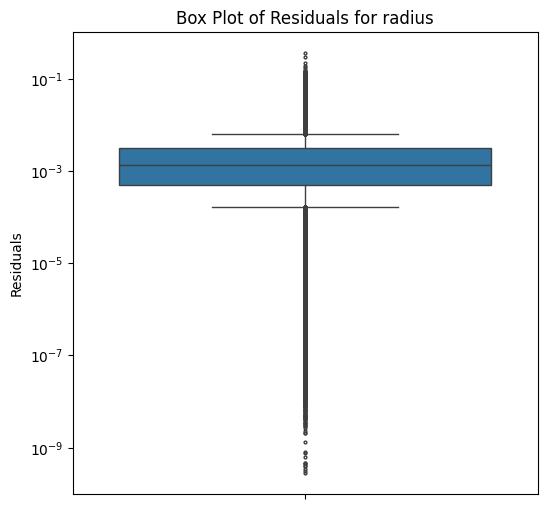

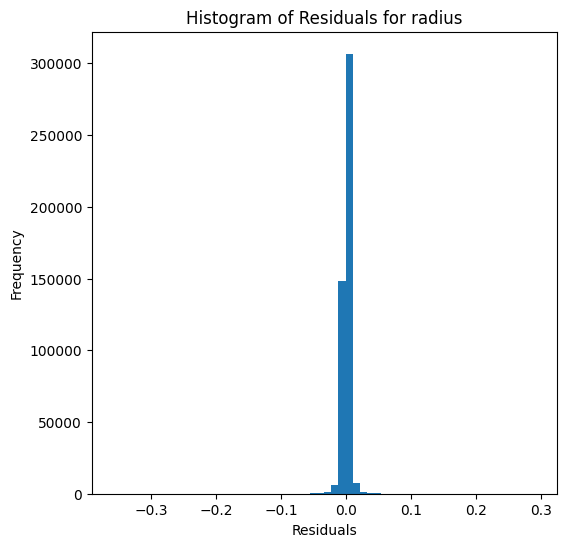

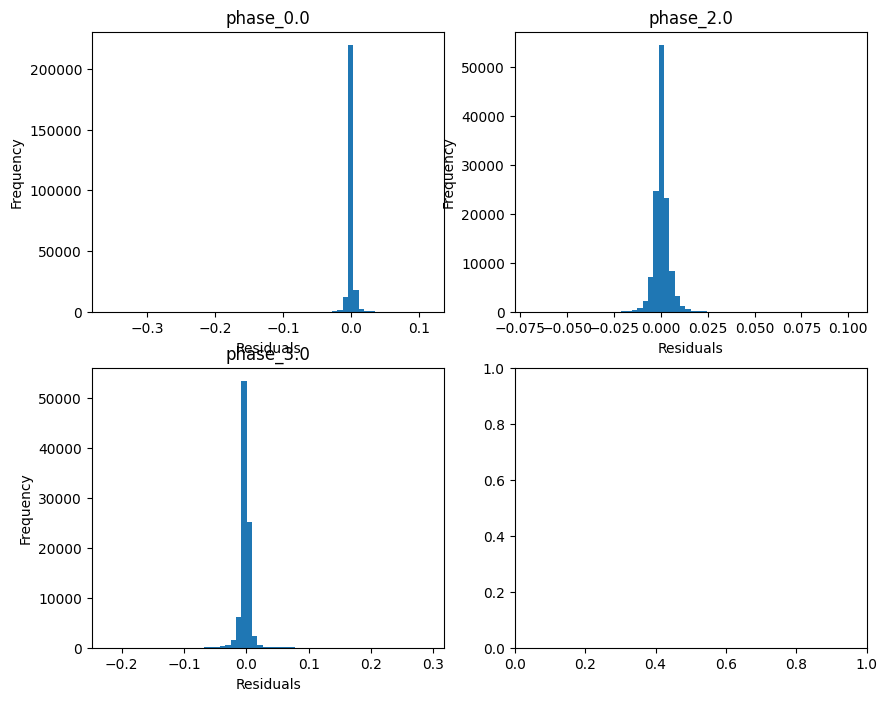

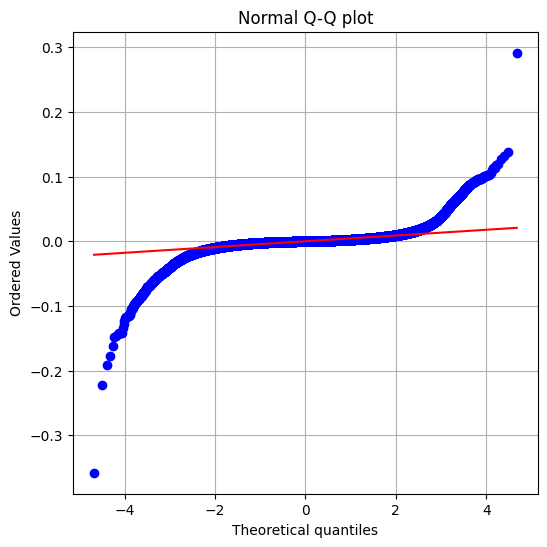

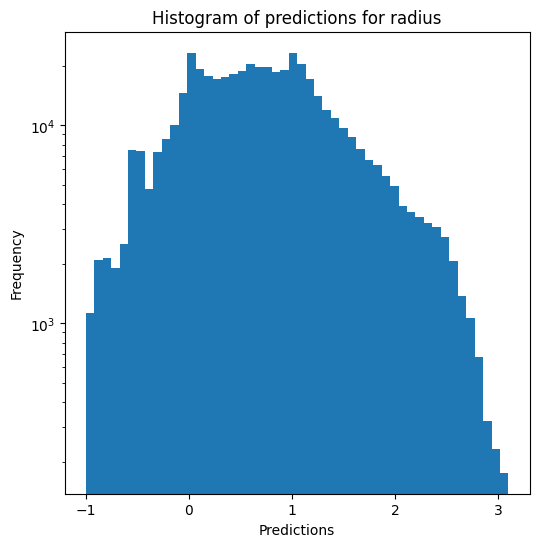

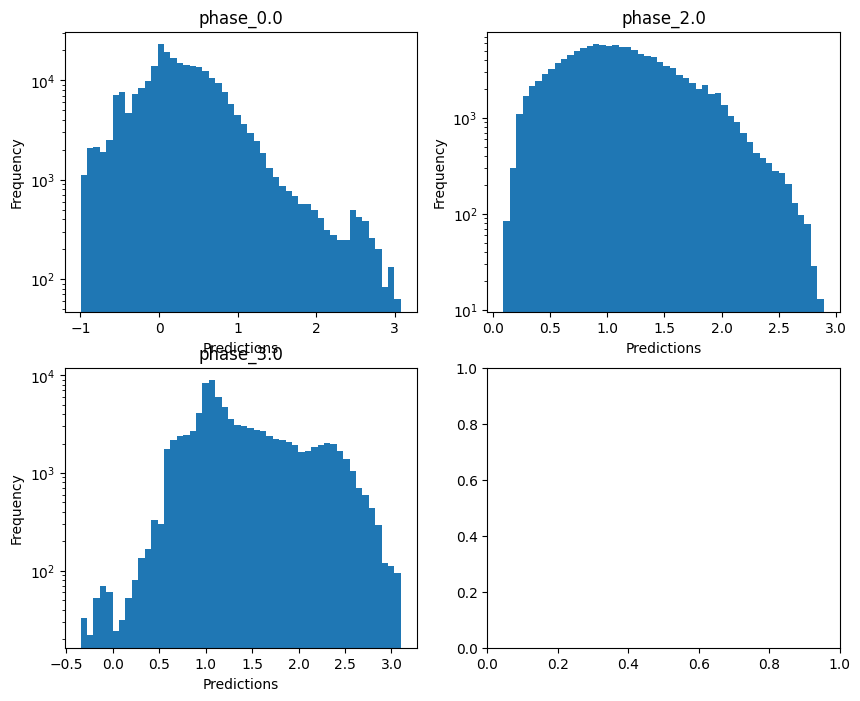

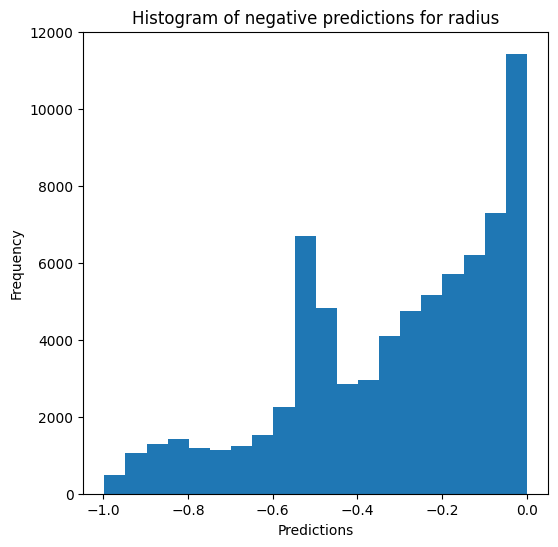

Saving results...


In [15]:
rf_evaluator.evaluate_Kfold_results(RandomForestRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=False, use_preds=True, save=True, show=True, n_jobs=5)
# average depth de 44-46

### XGBoost

In [16]:
xgb_evaluator = Model_evaluator("xgboost", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


Base train data :
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 298.5447575808816
  RVE :  0.9910072956179956
  RMSE :  2.494119573996689
  MAE :  0.6773915424575189
  MedAE :  0.12578609649357553
  CORR :  0.9955145412428942
  MAX_ER :  72.95365928611318
  Percentiles : 
    75th percentile :  0.3848369778327197
    90th percentile :  1.2895633422320578
    95th percentile :  2.6983724699299283
    99th percentile :  11.034491302904975

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 283.72102985530483
  RVE :  0.9988754736593098
  RMSE :  0.9959317895204074
  MAE :  0.29336744162478817
  MedAE :  0.07123763131807914
  CORR :  0.9994709362034415
  MAX_ER :  39.12064222195215
  Percentiles : 
    75th percentile :  0.1562658213764383
    90th percentile :  0.5480041757942958
    95th percentile :  1.3215092460814832
    99th percentile :  4.414407992232011

mass res

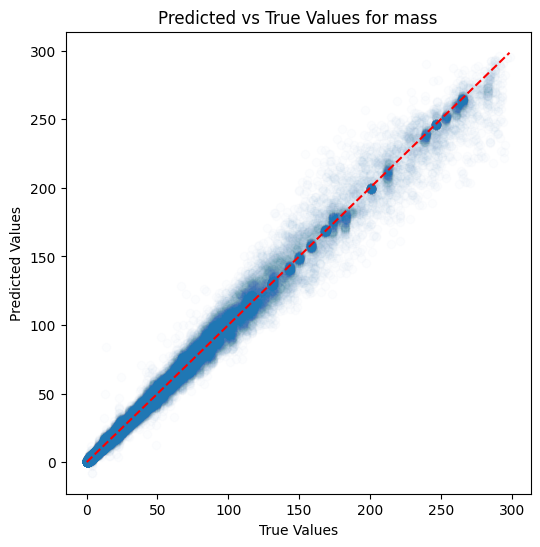

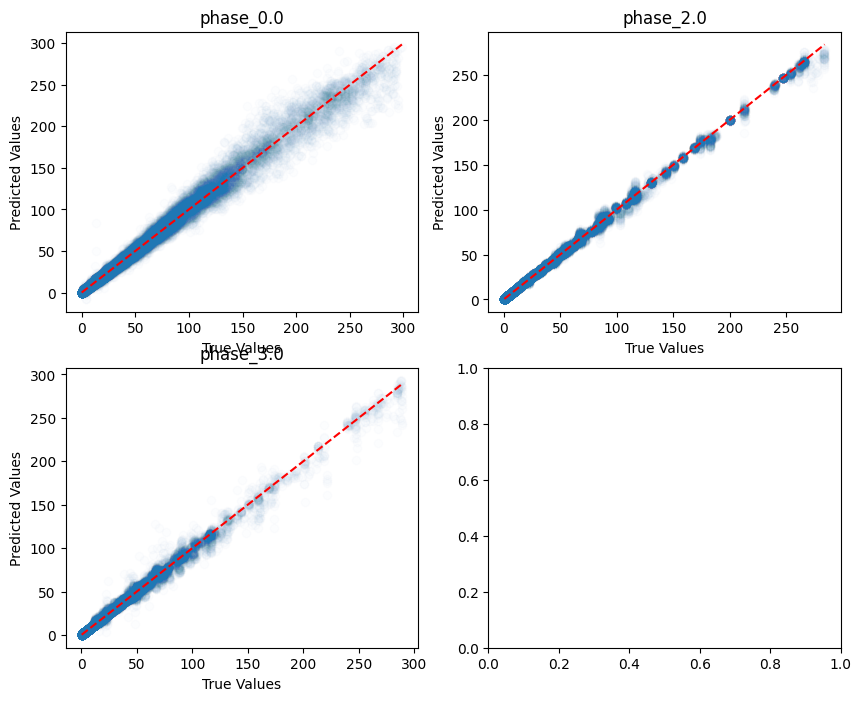

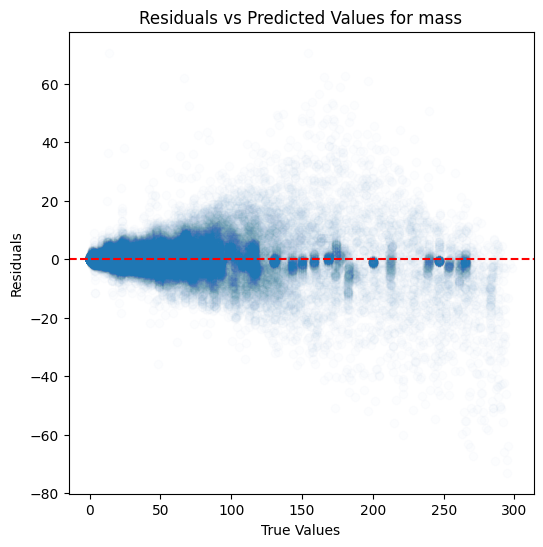

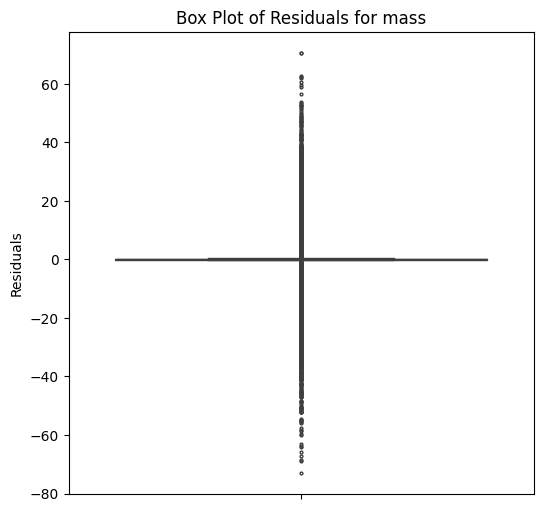

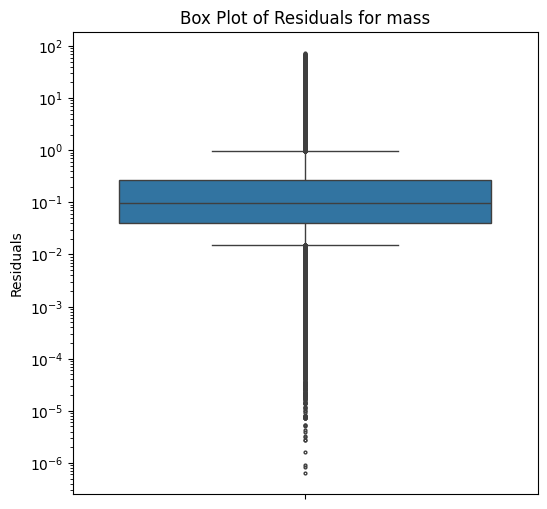

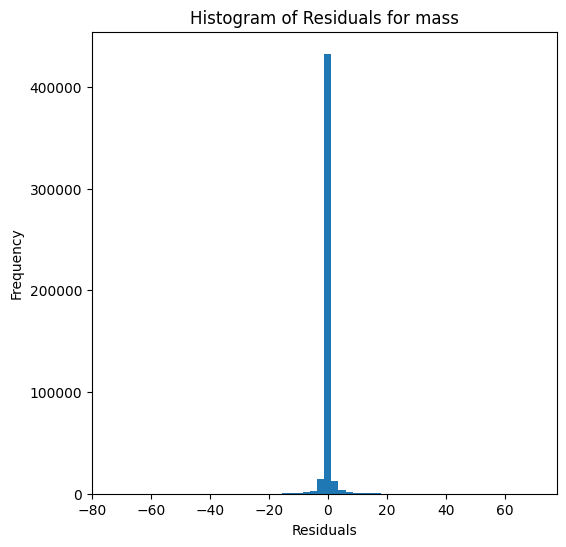

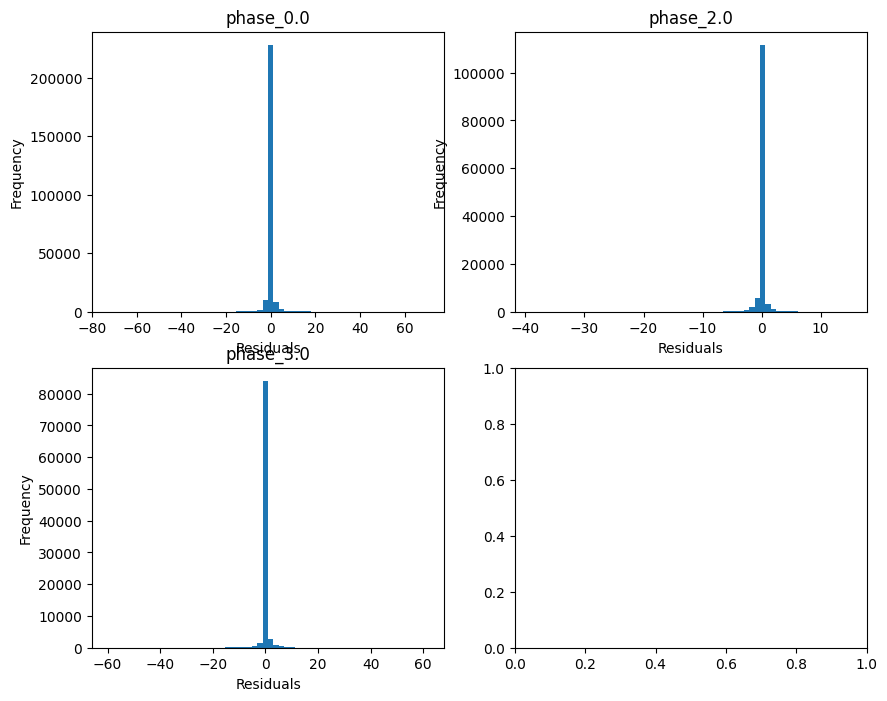

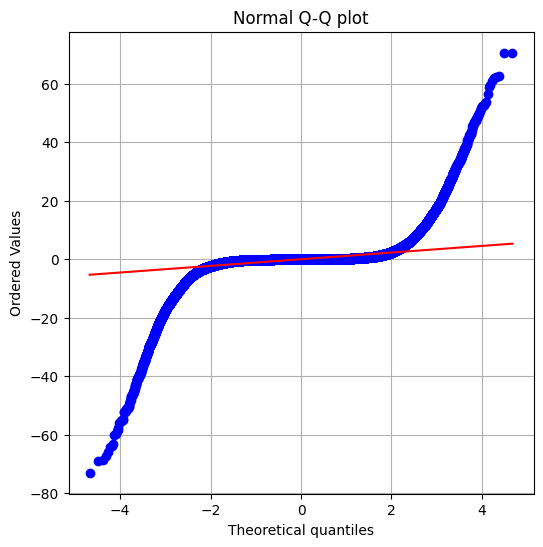

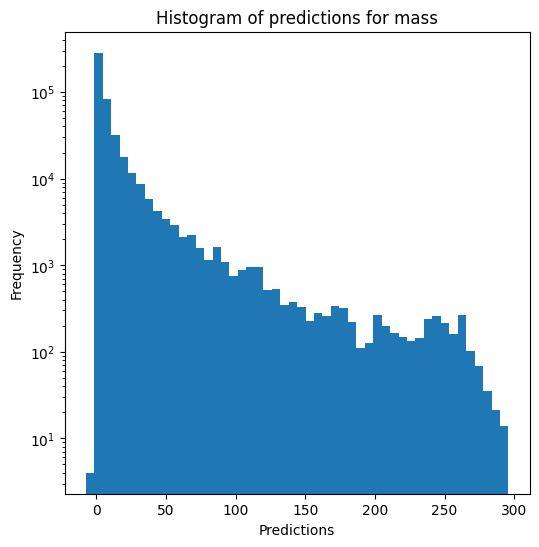

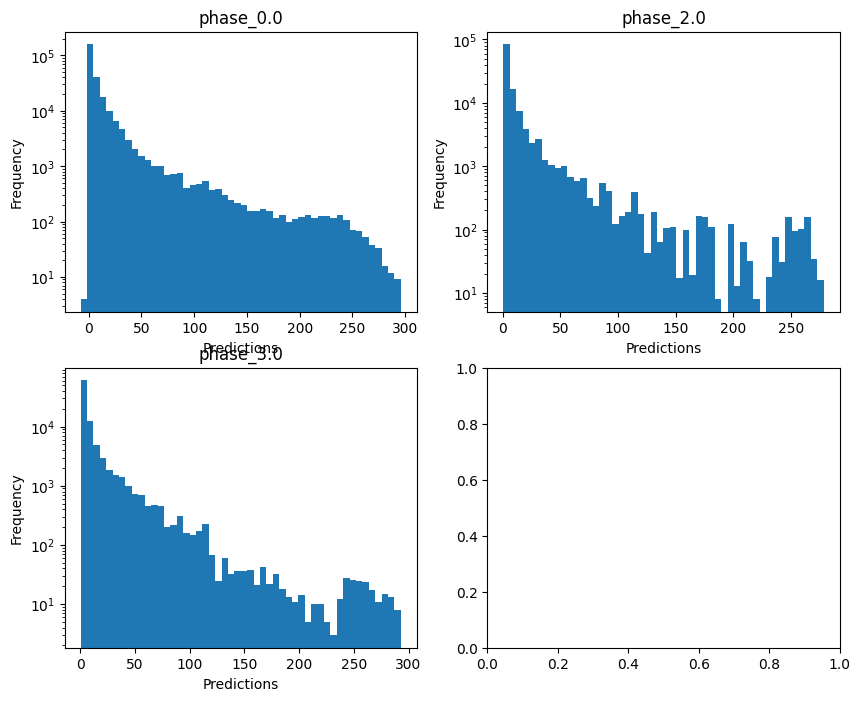

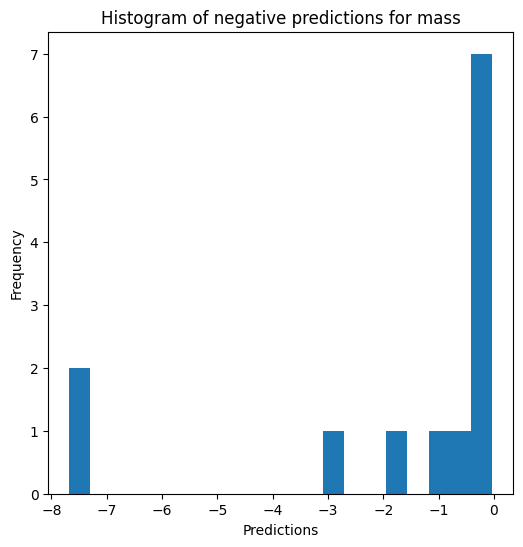


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9994380170169319
  RMSE :  0.013519559302933436
  MAE :  0.009938621244050263
  MedAE :  0.007491853811901372
  CORR :  0.9997190014385369
  MAX_ER :  0.13587362960448646
  Percentiles : 
    75th percentile :  0.013644835939643087
    90th percentile :  0.021510246049467083
    95th percentile :  0.027550861808119744
    99th percentile :  0.042245766054644064

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.891706235288321
  RVE :  0.9992306813494213
  RMSE :  0.013622268924976732
  MAE :  0.010655676089390474
  MedAE :  0.008759958874671847
  CORR :  0.9996159124585666
  MAX_ER :  0.07363099087913305
  Percentiles : 
    75th percentile :  0.015141496303952562
    90th percentile :  0.02219107123655535
    95th percentile :  0.02704115847432653
    99th percentile :  0.03758513399808328

radius results for t

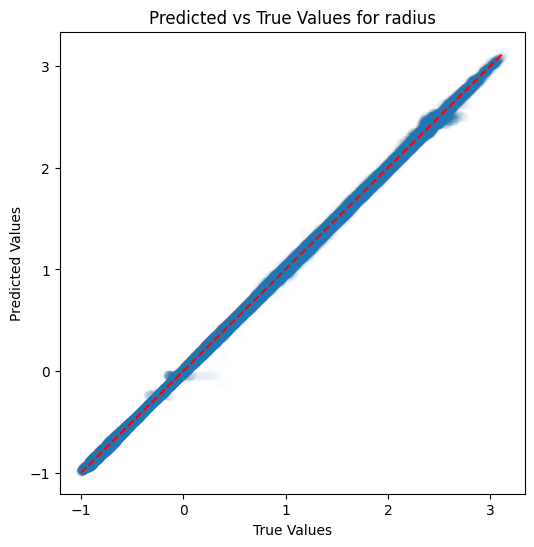

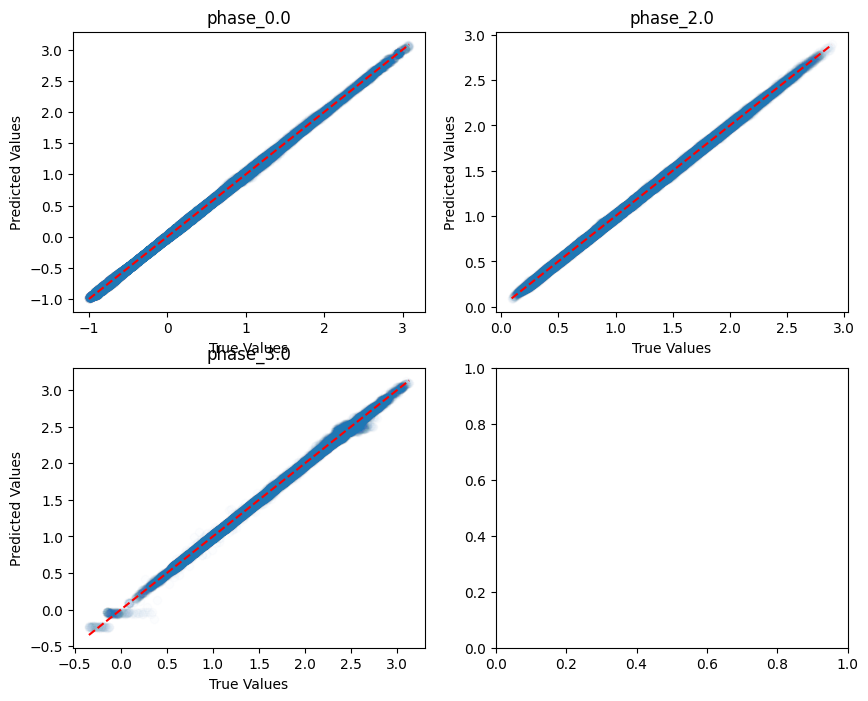

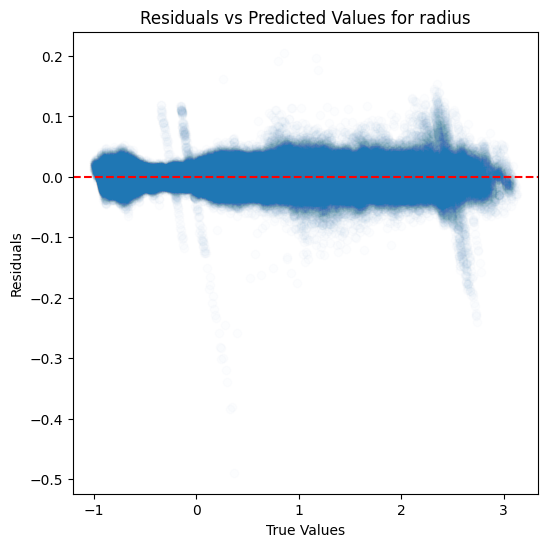

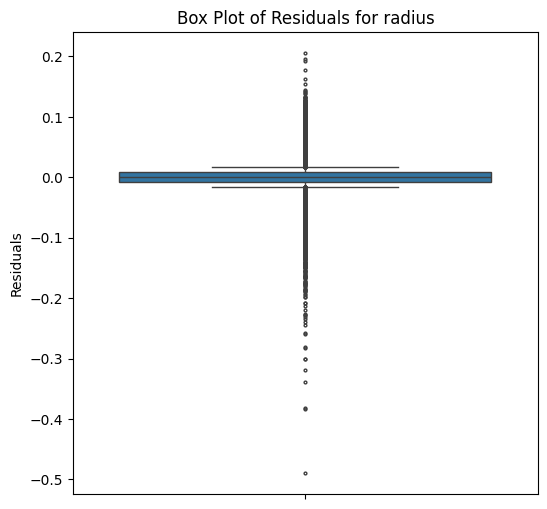

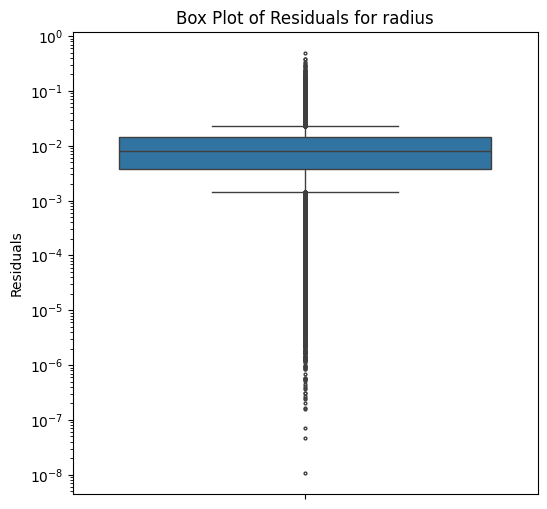

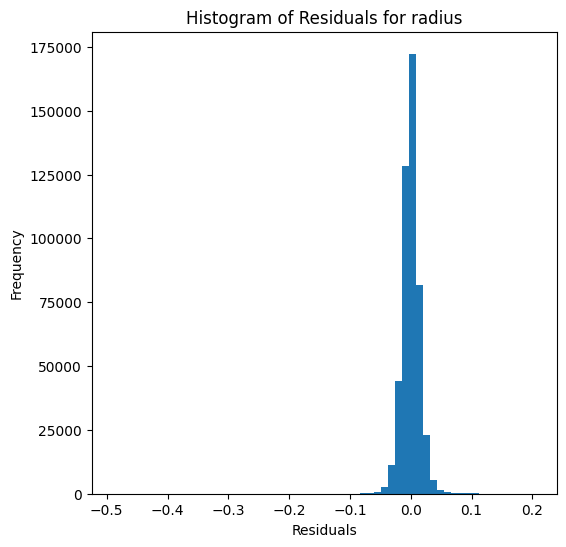

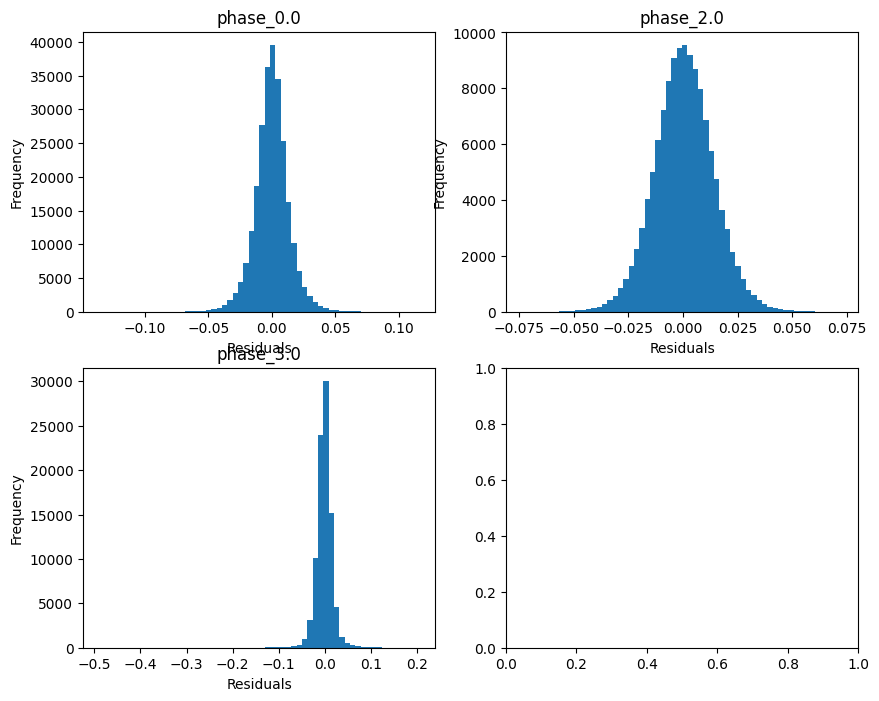

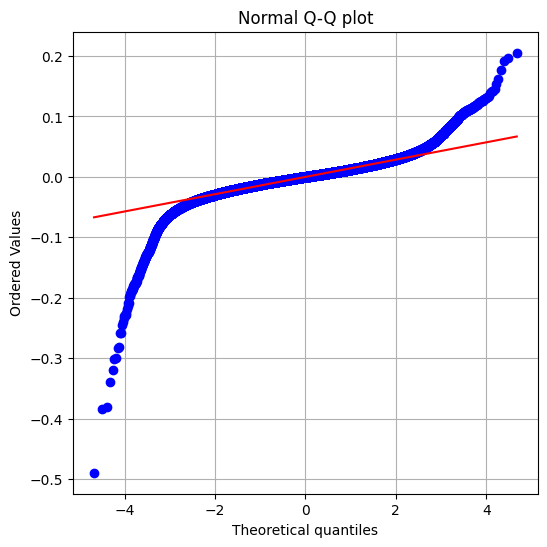

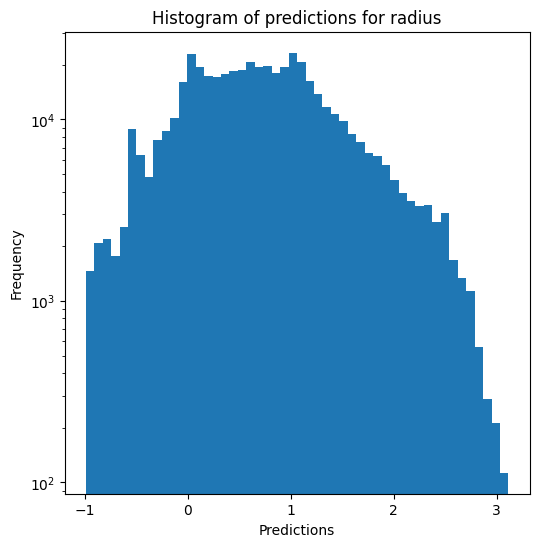

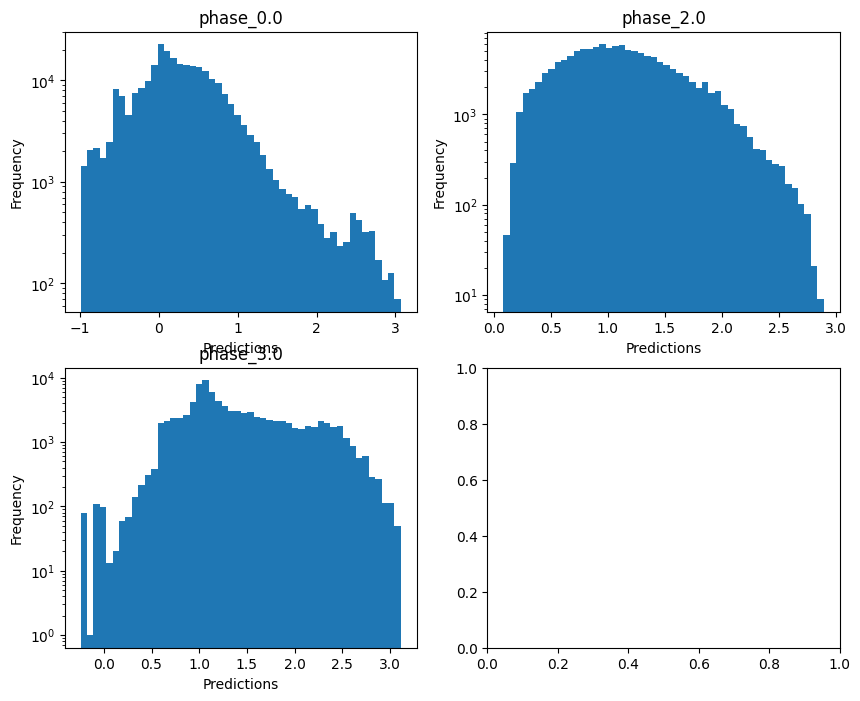

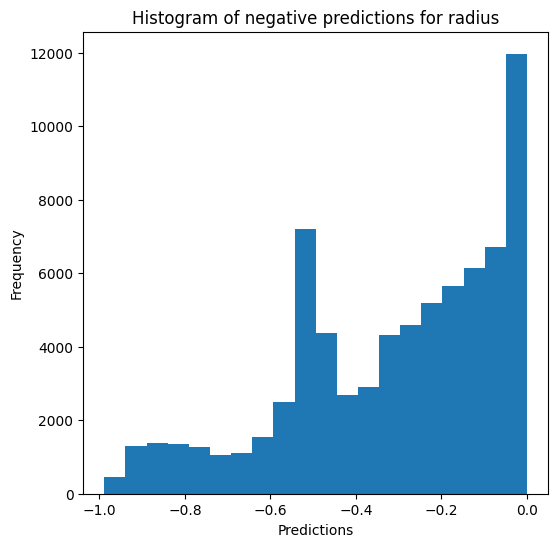

Saving results...


In [17]:
xgb_evaluator.evaluate_Kfold_results(XGBRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=False, use_preds=True, save=True, show=True, n_jobs=5)

### Multi-layer perceptron

In [18]:
mlp_evaluator = Model_evaluator("mlp", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


Base train data :
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 298.5447575808816
  RVE :  0.9649620036835357
  RMSE :  4.923128306127916
  MAE :  1.3415952237953057
  MedAE :  0.29043916463582464
  CORR :  0.9826529817996816
  MAX_ER :  127.1406465947268
  Percentiles : 
    75th percentile :  0.6448727078646532
    90th percentile :  2.458424369071201
    95th percentile :  5.634687190976298
    99th percentile :  21.937463468535096

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 283.72102985530483
  RVE :  0.9809873465478306
  RMSE :  4.1025447018224765
  MAE :  1.0928917274409464
  MedAE :  0.2631247976663317
  CORR :  0.9906440264736001
  MAX_ER :  92.62233332462321
  Percentiles : 
    75th percentile :  0.5051111666216244
    90th percentile :  1.6738625241186582
    95th percentile :  4.22263134015926
    99th percentile :  20.098873621890625

mass results 

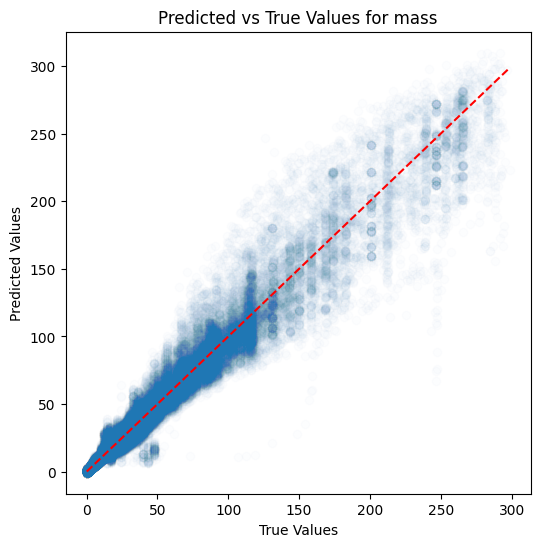

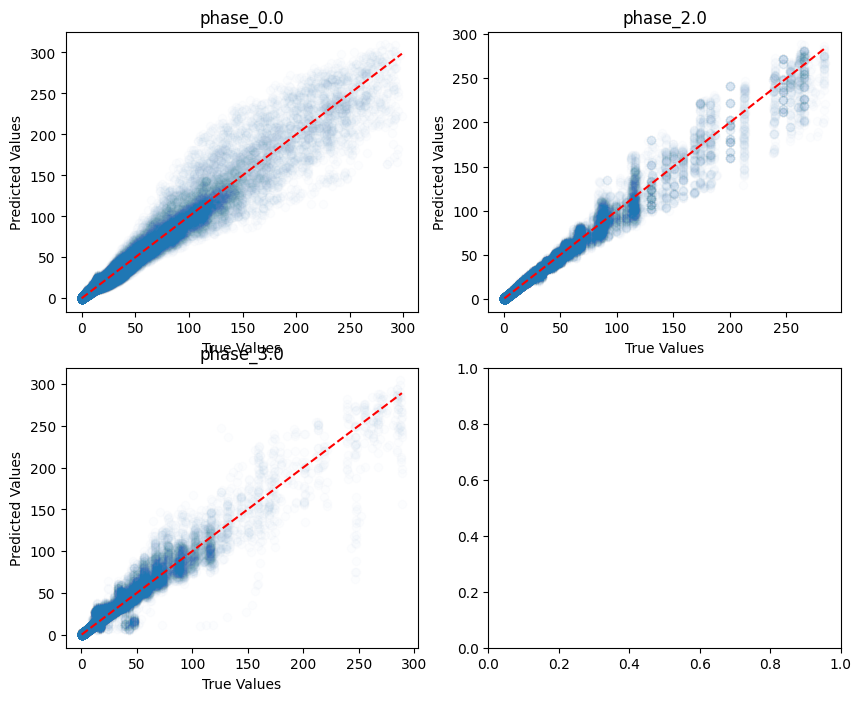

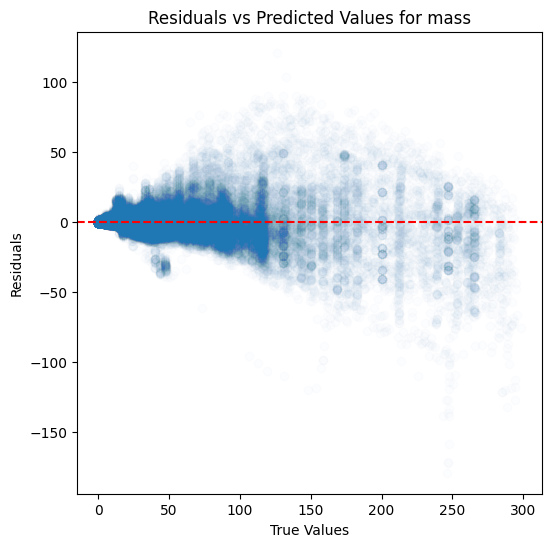

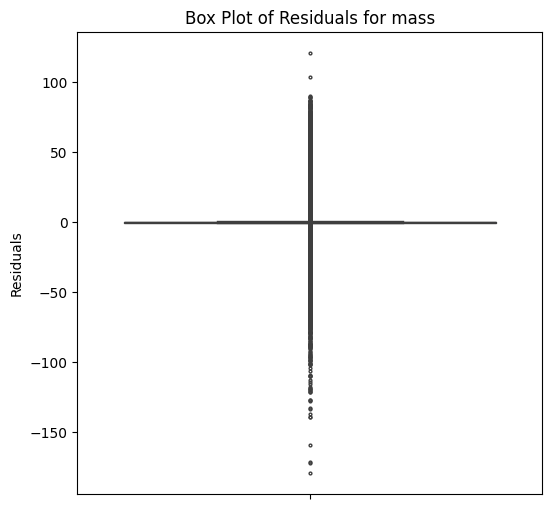

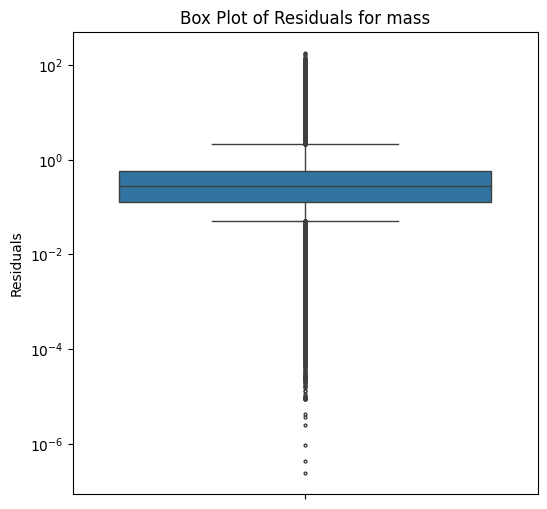

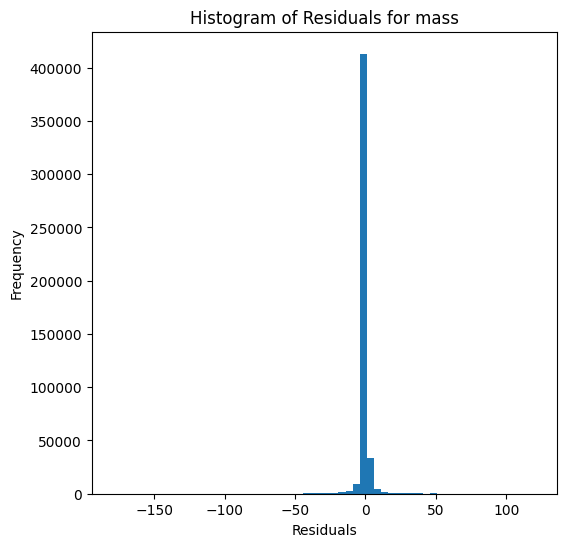

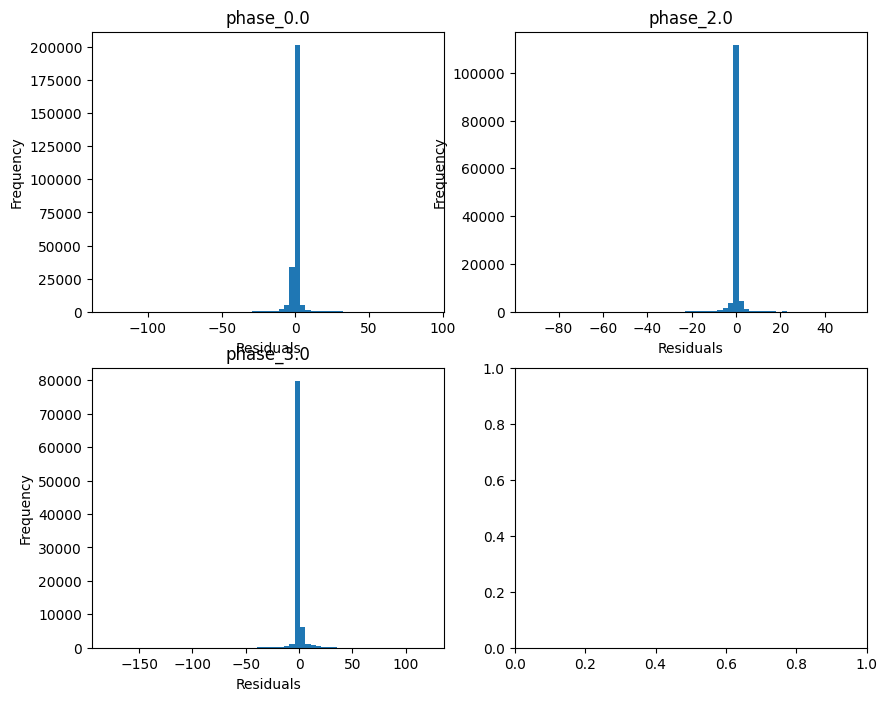

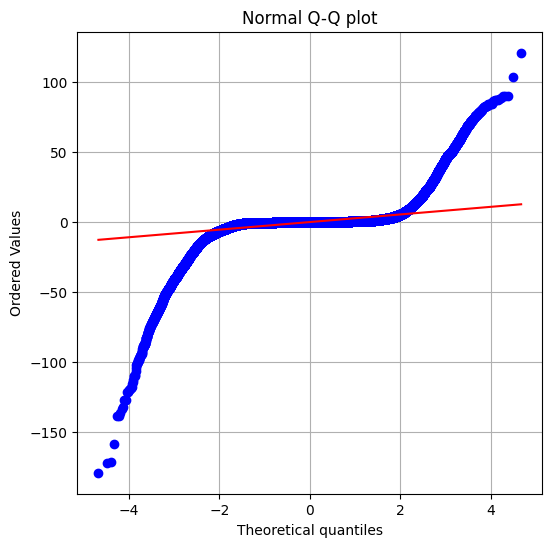

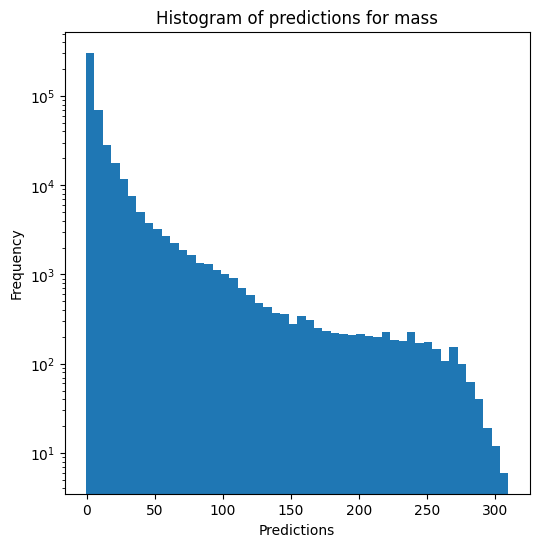

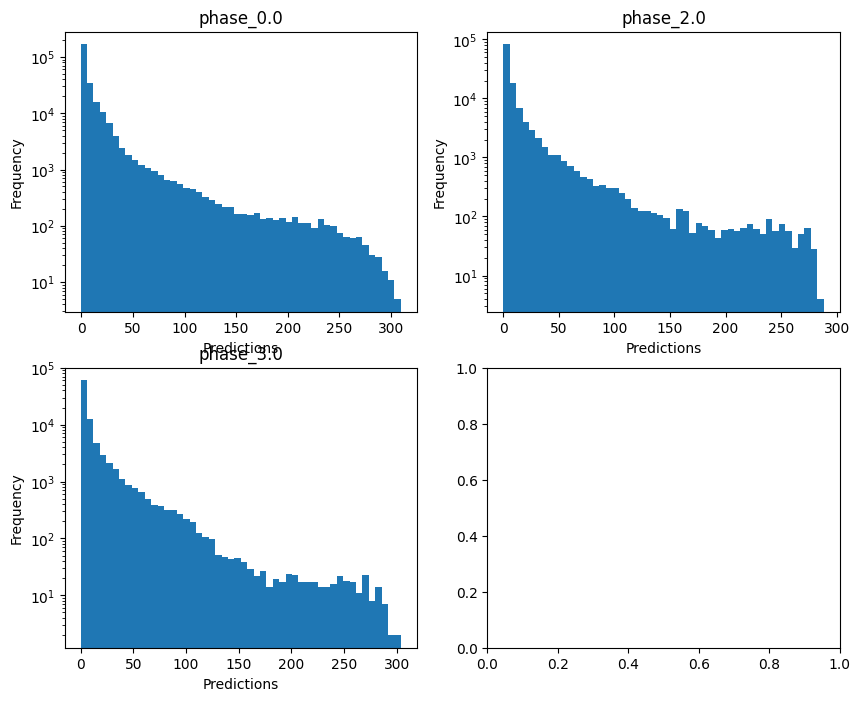

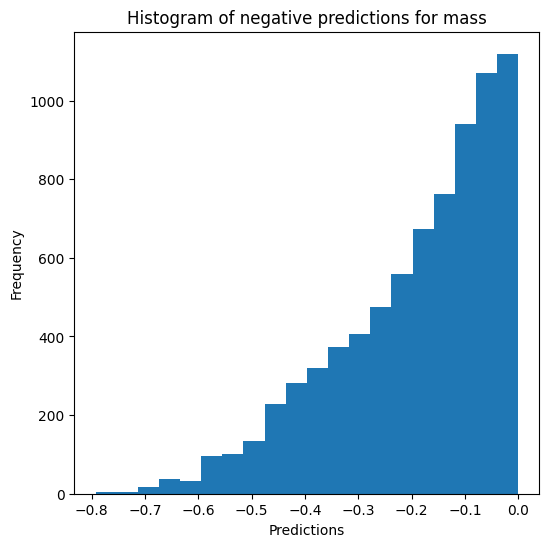


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9805982657945825
  RMSE :  0.07949782527795882
  MAE :  0.05721102163674451
  MedAE :  0.04276707972194656
  CORR :  0.9902516624078949
  MAX_ER :  0.6916305145208586
  Percentiles : 
    75th percentile :  0.076774879364902
    90th percentile :  0.12233911464746805
    95th percentile :  0.15977243584825715
    99th percentile :  0.26867621396247465

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.891706235288321
  RVE :  0.9810277123198489
  RMSE :  0.06759593383663778
  MAE :  0.05031571891803478
  MedAE :  0.03871324102222096
  CORR :  0.990582797331655
  MAX_ER :  0.40265365537442777
  Percentiles : 
    75th percentile :  0.06978783852276135
    90th percentile :  0.10691601591383088
    95th percentile :  0.1379179318576236
    99th percentile :  0.21054280766668035

radius results for the phase categor

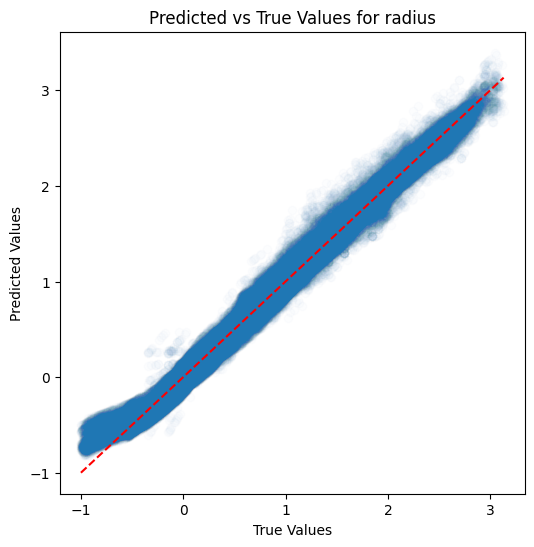

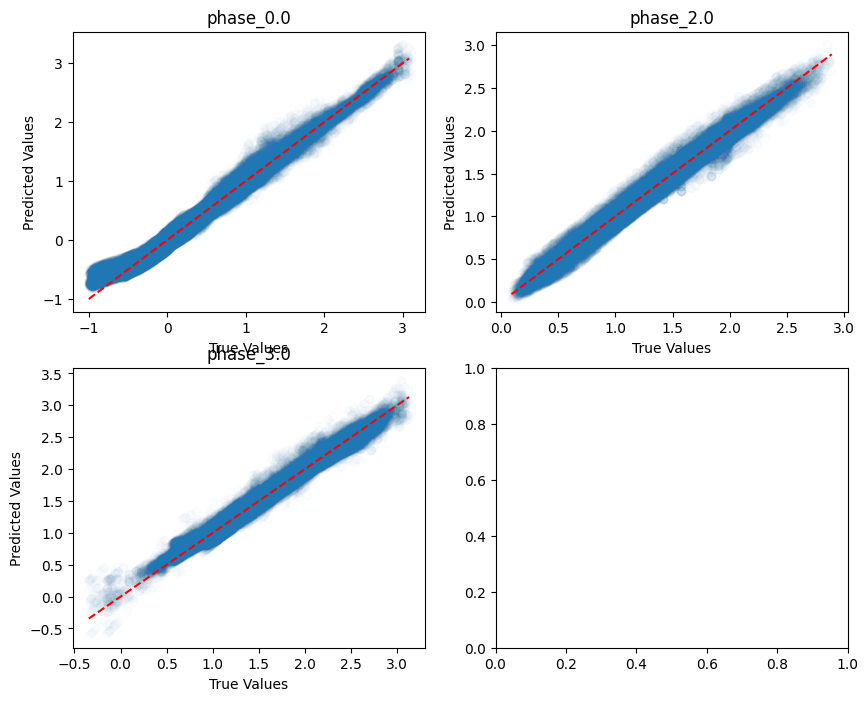

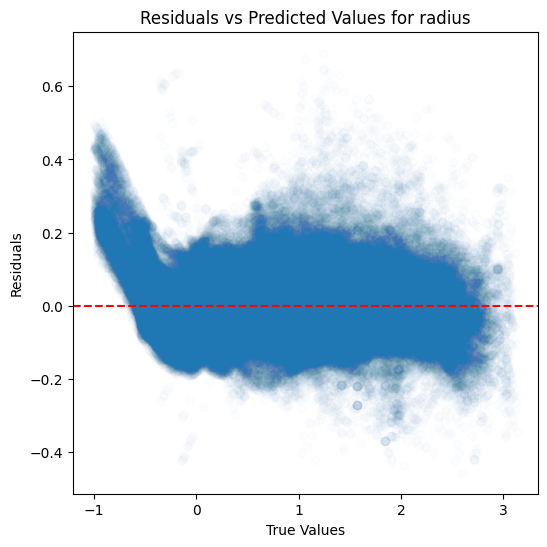

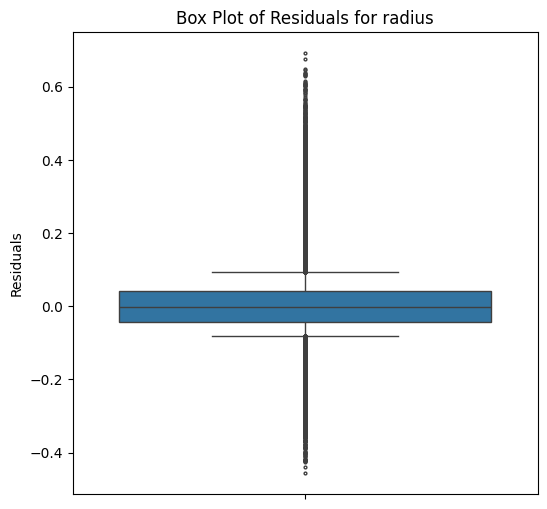

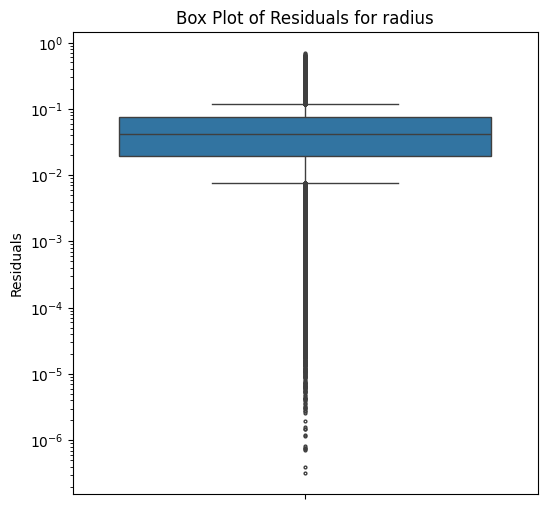

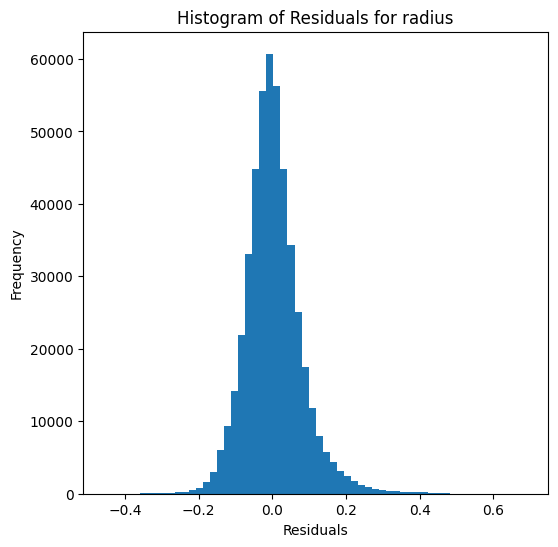

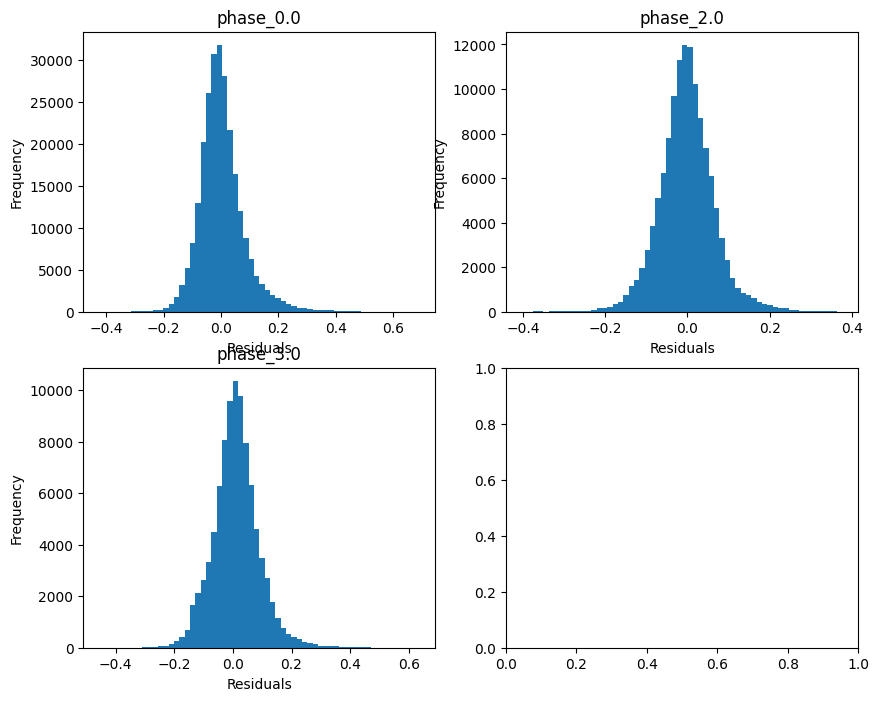

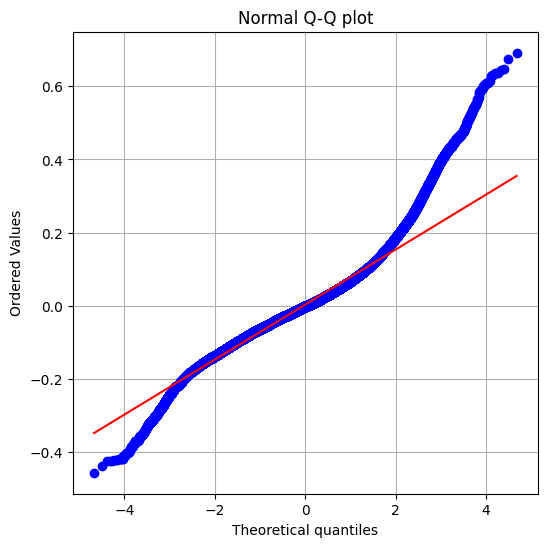

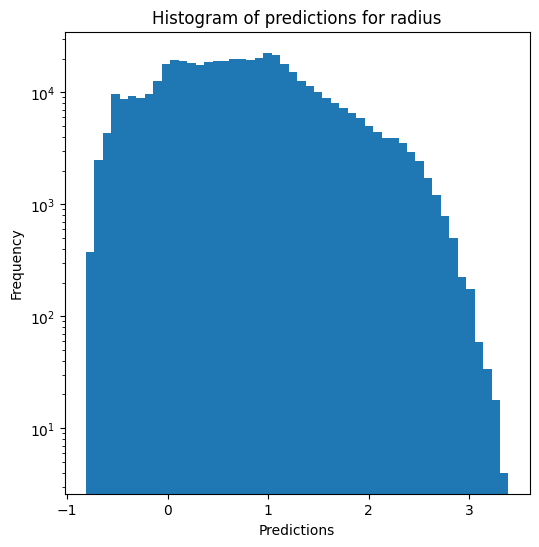

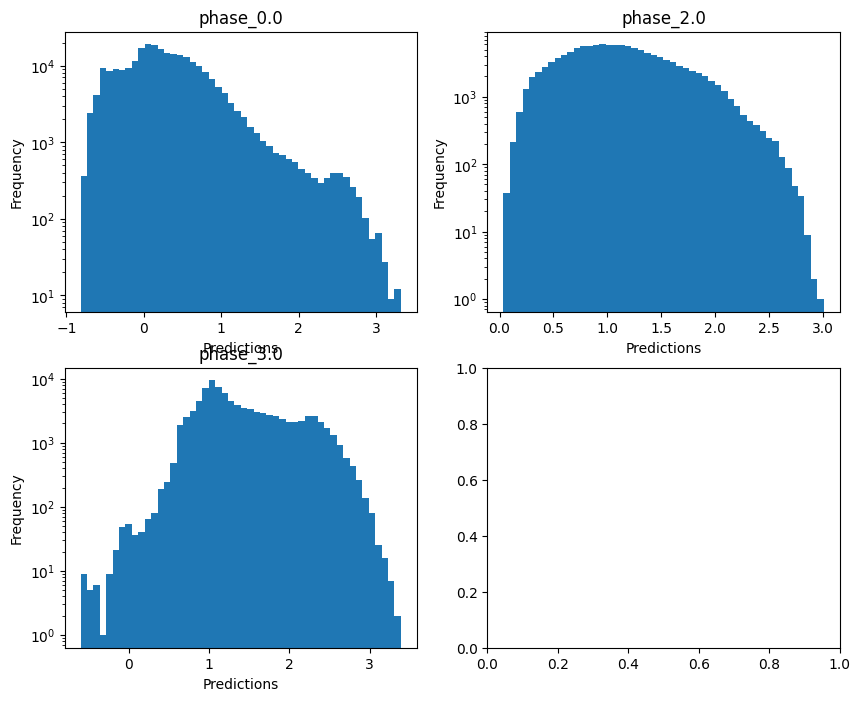

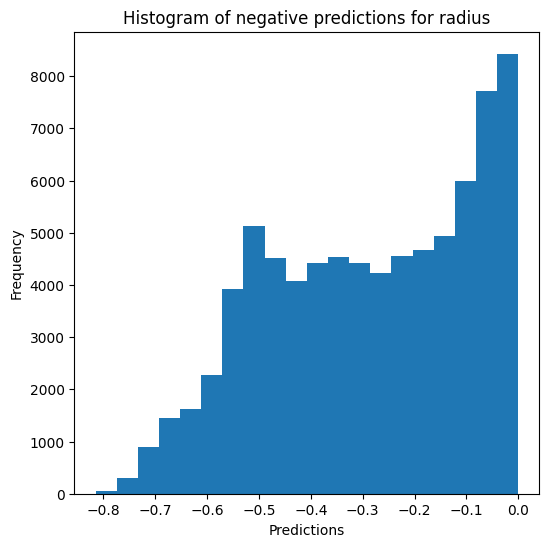

Saving results...


In [19]:
mlp_evaluator.evaluate_Kfold_results(MLPRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=False, use_preds=True, save=True, show=True,
                                      hidden_layer_sizes = (100, 100, 100, 100), max_iter=20, batch_size=400)

Avec batch_size=auto (200):

plus de 30 minutes pour entrainer un seul split de Kfold avec les paramètres par défaut (1 hidden layer de taille 100)

plus de 15 minutes pour entrainer un seul split de Kfold avec les 1 hidden layer de taille 10

- et max_iter=20, hidden_layer_sizes=(100, 50, 25): ~5 minutes par fold (plutôt bon résultats)
- et max_iter=20, hidden_layer_sizes=(100, 100, 100): ~5 minutes par fold

Avec batch_size=400:


Avec learning_rate= :


hidden_layer_sizes = (100, 100), max_iter=20, batch_size=200 => 17 min pour 2 splits et min_loss de 2.1
RMSE = RVE :  0.984867927459382
RMSE :  2.5335132759292107
MAE :  0.7276983504493552
MedAE :  0.3034009994265745
CORR :  0.9927285673947535
MAX_ER :  169.74348568157313
Percentiles : 75th percentile :  0.5113604728134682 90th percentile :  1.1025928446049704 95th percentile :  2.1347654852226015 99th percentile :  9.897101952249908)

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=400 => 7 min pour 2 splits et min_loss de 2.2
RVE :  0.9797171492755655
RMSE :  2.983208723004754
MAE :  0.9125599339275378
MedAE :  0.43124518658659683
CORR :  0.9920536596906272
MAX_ER :  170.53076478793002
Percentiles : 75th percentile :  0.675744507049632 90th percentile :  1.2421052024331438 95th percentile :  2.441733387262636 99th percentile :  11.925724226452427

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=800 => 3 min pour 2 splits et min_loss de 2.3 et 2.7

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=1600 => 3 min 30 pour 2 splits et min_loss de 7.8 et 3.8

=> batch_size plus grand == plus rapide mais moins bon